# Text Mining Project - Data Exploration
**Spring Semester 2025/2026**

Group 11:
- Ana Macedo
- Carlota Pires
- Francisca Calçoa
- Francisca Martins

This notebook covers **Section 1 – Data Exploration** of the project requirements.


## 1. Imports and Setup

In [ ]:
# !pip install wordcloud
# !pip install emoji
# !pip install fasttext-wheel
# !pip install sentencepiece
#!pip install transformers accelerate torch
# !pip install transformers[Trainer]
# !pip install 'accelerate>=1.1.0'




[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
import gensim
import gensim.downloader
import joblib
from transformers import (
    MarianMTModel, MarianTokenizer, pipeline
)
import torch
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

from wordcloud import WordCloud
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
#for splitting data
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import nltk
from nltk.tokenize import word_tokenize
import urllib.request

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer
from gensim.models import Word2Vec

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



# Additional libraries for advanced modeling and preprocessing

import fasttext
import scipy.sparse
import os
import numpy as np
import scipy.sparse
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import xgboost as xgb
from scipy import sparse
from sklearn.model_selection import GridSearchCV


import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from sklearn.model_selection import GridSearchCV


#extra
import torch
from tqdm.auto import tqdm
from transformers import (
    BertTokenizer, BertModel, RobertaTokenizer, RobertaModel,
    MarianMTModel, MarianTokenizer, AutoTokenizer, AutoModel, pipeline
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score


## 2. Load the Data

In [71]:
train = pd.read_csv('../Datasets/train.csv')
test = pd.read_csv('../Datasets/test.csv')

In [72]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Label mapping for readability
label_map  = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
label_colors = {'Bearish': '#e58181', 'Bullish': '#c4ebc4', 'Neutral': '#fff3b1'}

# Add readable label column
train['sentiment'] = train['label'].map(label_map)

## 3. Basic Dataset Overview

In [73]:
#Verification of the loaded data
print(f'Train set : {train.shape[0]:,} tweets, {train.shape[1]} columns')
print(f'Test set  : {test.shape[0]:,} tweets, {test.shape[1]} columns')
train.head(10)

Train set : 9,543 tweets, 3 columns
Test set  : 2,388 tweets, 2 columns


,text,label,sentiment
0,$BYND - JPMorgan reels in expectations on Beyo...,0,Bearish
1,$CCL $RCL - Nomura points to bookings weakness...,0,Bearish
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,Bearish
3,$ESS: BTIG Research cuts to Neutral https://t....,0,Bearish
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,Bearish
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0,Bearish
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0,Bearish
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0,Bearish
8,$GTT: Cowen cuts to Market Perform,0,Bearish
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0,Bearish


In [74]:
train.tail(10)

,text,label,sentiment
9533,"Stocks making the biggest moves midday: Tesla,...",2,Neutral
9534,"Stocks making the biggest moves midday: Tesla,...",2,Neutral
9535,"Stocks making the biggest moves midday: Uber, ...",2,Neutral
9536,Stocks making the biggest moves premarket: Tar...,2,Neutral
9537,Stocks making the biggest moves premarket: TD ...,2,Neutral
9538,The Week's Gainers and Losers on the Stoxx Eur...,2,Neutral
9539,Tupperware Brands among consumer gainers; Unil...,2,Neutral
9540,vTv Therapeutics leads healthcare gainers; Myo...,2,Neutral
9541,"WORK, XPO, PYX and AMKR among after hour movers",2,Neutral
9542,"YNDX, I, QD and OESX among tech movers",2,Neutral


In [75]:
print(f'Training set Duplicates: {train.duplicated(subset="text").sum()}')

Training set Duplicates: 0


In [76]:
print('Data Types:')
print(train.dtypes)
print()
print('Missing Values:')
print(train.isnull().sum())
print()
print('Test Set Columns:')
print(test.columns.tolist())
print(test.head(3))

Data Types:
text         object
label         int64
sentiment    object
dtype: object

Missing Values:
text         0
label        0
sentiment    0
dtype: int64

Test Set Columns:
['id', 'text']
   id                                               text
0   0  ETF assets to surge tenfold in 10 years to $50...
1   1  Here’s What Hedge Funds Think Evolution Petrol...
2   2  $PVH - Phillips-Van Heusen Q3 2020 Earnings Pr...


In [77]:
print(train['label'].describe())
print(f"\nUnique values: {sorted(train['label'].unique())}")

count    9543.000000
mean        1.496280
std         0.743139
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         2.000000
Name: label, dtype: float64

Unique values: [0, 1, 2]


## 4. Class Distribution

Understanding class balance is critical: if one class dominates, a naive classifier that always predicts that class will have artificially high accuracy.

In [78]:
counts = train['label'].value_counts().sort_index()
total  = len(train)

print('Class distribution (training set):')
for label, count in counts.items():
    name = label_map[label]
    print(f'  {name:8s} ({label}): {count:,}  ({count / total * 100:.1f}%)')

majority_acc = counts.max() / total * 100
print(f'\nMajority-class baseline accuracy: {majority_acc:.1f}%')
print('-> A model must beat this to be useful.')

Class distribution (training set):
  Bearish  (0): 1,442  (15.1%)
  Bullish  (1): 1,923  (20.2%)
  Neutral  (2): 6,178  (64.7%)

Majority-class baseline accuracy: 64.7%
-> A model must beat this to be useful.


**Conclusions:**
- The dataset is imbalanced: ~64.7% of tweets are Neutral, while Bearish (15.1%) and Bullish (20.2%) are underrepresented.
- The majority-class baseline achieves ~64.7% accuracy.
- Class imbalance must be addressed during preprocessing and modelling through for example class weights or oversampling.

Through the class imbalanced, we will choose the F1-score as our evaluation metric. Accuracy can be misleading in imbalanced datasets, as a model could achieve high accuracy by simply predicting the majority class. The F1-score, on the other hand, considers both precision and recall, providing a more balanced evaluation of model performance.

In [79]:
train['word_count'] = train['text'].apply(lambda x: len(str(x).split()))
train['char_count'] = train['text'].apply(lambda x: len(str(x)))

print('Word count statistics by class:')
print(train.groupby('sentiment')['word_count'].describe().round(2))

Word count statistics by class:
            count   mean   std  min  25%   50%   75%   max
sentiment                                                 
Bearish    1442.0  12.00  4.31  3.0  9.0  11.0  15.0  32.0
Bullish    1923.0  11.93  4.32  2.0  9.0  11.0  14.0  29.0
Neutral    6178.0  12.30  4.84  1.0  9.0  12.0  16.0  29.0


**Conclusion:** Tweets are generally short (~12 words on average), consistent across all three classes.


C:\Users\calco\AppData\Local\Temp\ipykernel_35752\3385815743.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


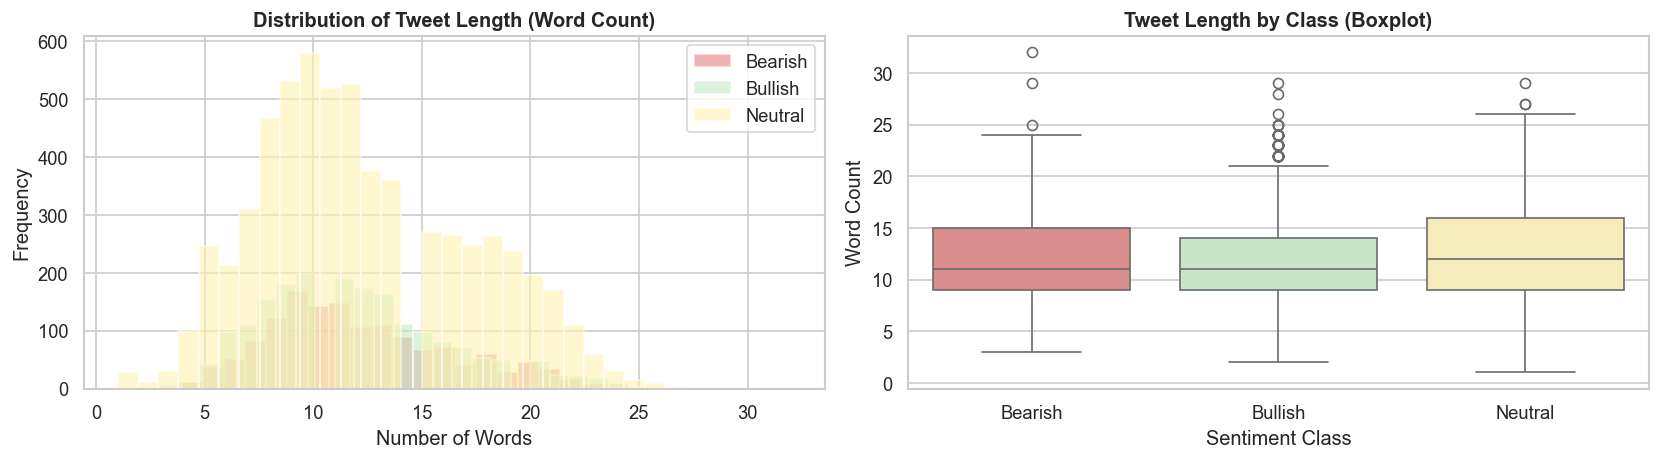

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label_id, label_name in label_map.items():
    subset = train[train['label'] == label_id]['word_count']
    axes[0].hist(subset, bins=30, alpha=0.6, label=label_name,
                 color=label_colors[label_name],
                 edgecolor='white')

axes[0].set_title('Distribution of Tweet Length (Word Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(
    data=train, x='sentiment', y='word_count',
    palette=label_colors,
    order=['Bearish', 'Bullish', 'Neutral'],
    ax=axes[1]
)

axes[1].set_title('Tweet Length by Class (Boxplot)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('tweet_length.png', bbox_inches='tight')
plt.show()

In [81]:
train['has_ticker']  = train['text'].apply(lambda x: bool(re.search(r'\$[A-Z]{1,5}', x)))
train['has_hashtag'] = train['text'].apply(lambda x: bool(re.search(r'#\w+', x)))
train['has_url']     = train['text'].apply(lambda x: bool(re.search(r'http', x)))

feature_cols = ['has_ticker', 'has_hashtag', 'has_url']
feature_labels = ['Stock Ticker ($)', 'Hashtag (#)', 'URL (http)']

print('Presence of Twitter-specific features (% of tweets):')
for col, lbl in zip(feature_cols, feature_labels):
    print(f'  {lbl:20s}: {train[col].mean()*100:.1f}%')

Presence of Twitter-specific features (% of tweets):
  Stock Ticker ($)    : 15.0%
  Hashtag (#)         : 9.4%
  URL (http)          : 46.8%


**Conclusions:**
- Stock tickers like `$AAPL` and `$TSLA` appear in ~15% of tweets and are specific to financial sentiment
- Hashtags appear in ~9% of tweets, so their contribution to sentiment may vary.
- URLs are present in ~47% of tweets. They carry no semantic value and should be removed during preprocessing.

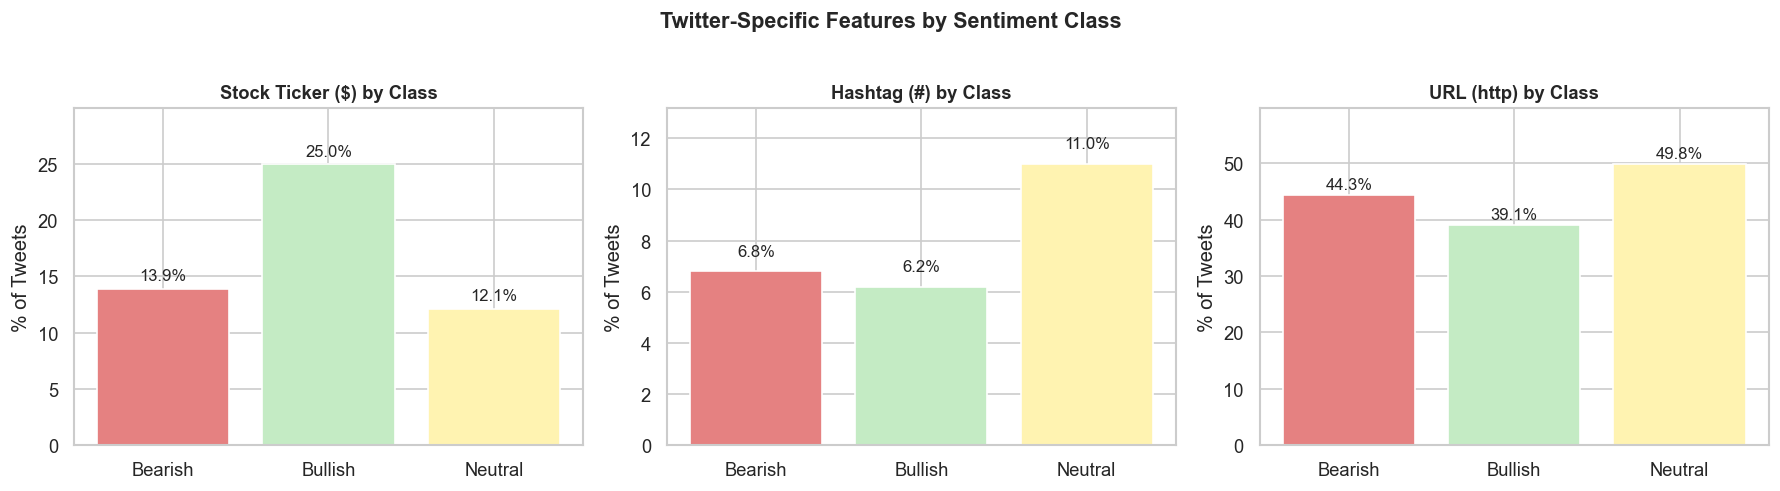

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, lbl in zip(axes, feature_cols, feature_labels):
    data = train.groupby('sentiment')[col].mean() * 100
    data = data.reindex(['Bearish', 'Bullish', 'Neutral'])
    colors = [label_colors[k] for k in ['Bearish', 'Bullish', 'Neutral']]
    bars = ax.bar(data.index, data.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{lbl} by Class', fontsize=11, fontweight='bold')
    ax.set_ylabel('% of Tweets')
    ax.set_ylim(0, data.max() * 1.2)

plt.suptitle('Twitter-Specific Features by Sentiment Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('twitter_features.png', bbox_inches='tight')
plt.show()

**Conclusions:**
- Stock Tickers ($): Bullish has 25% vs Bearish 13.9%. This means that tweets with tickers are more associated with positive sentiment.
- Hashtags (#): Little difference between classes (6-11%), so they have low discriminative power.
- URLs (http): Appear a lot across all classes relatively uniformly, so they do not distinguish sentiment and should be removed in preprocessing. 

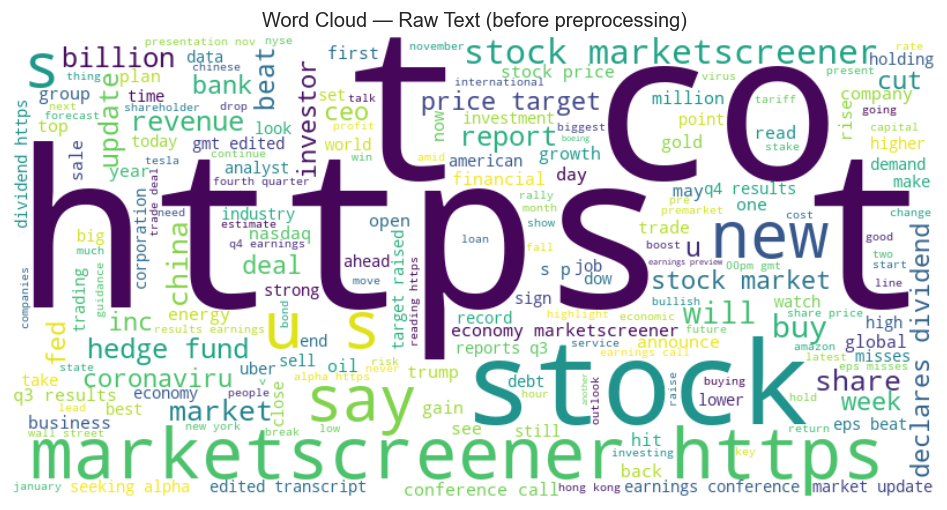

In [83]:
# Word Cloud — Raw Text
raw_text = ' '.join(train['text'].fillna('')).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Raw Text (before preprocessing)')
plt.show()

On word clouds (raw text) it's possible to see the most common words in the dataset, but they are not very informative due to the presence of stopwords, punctuation, and other noise. After preprocessing, we will be able to see more meaningful words that are relevant to the sentiment analysis task. Otherwise, "https", "stock" and "marketscreener" are examples of common words that appear in the raw word cloud.

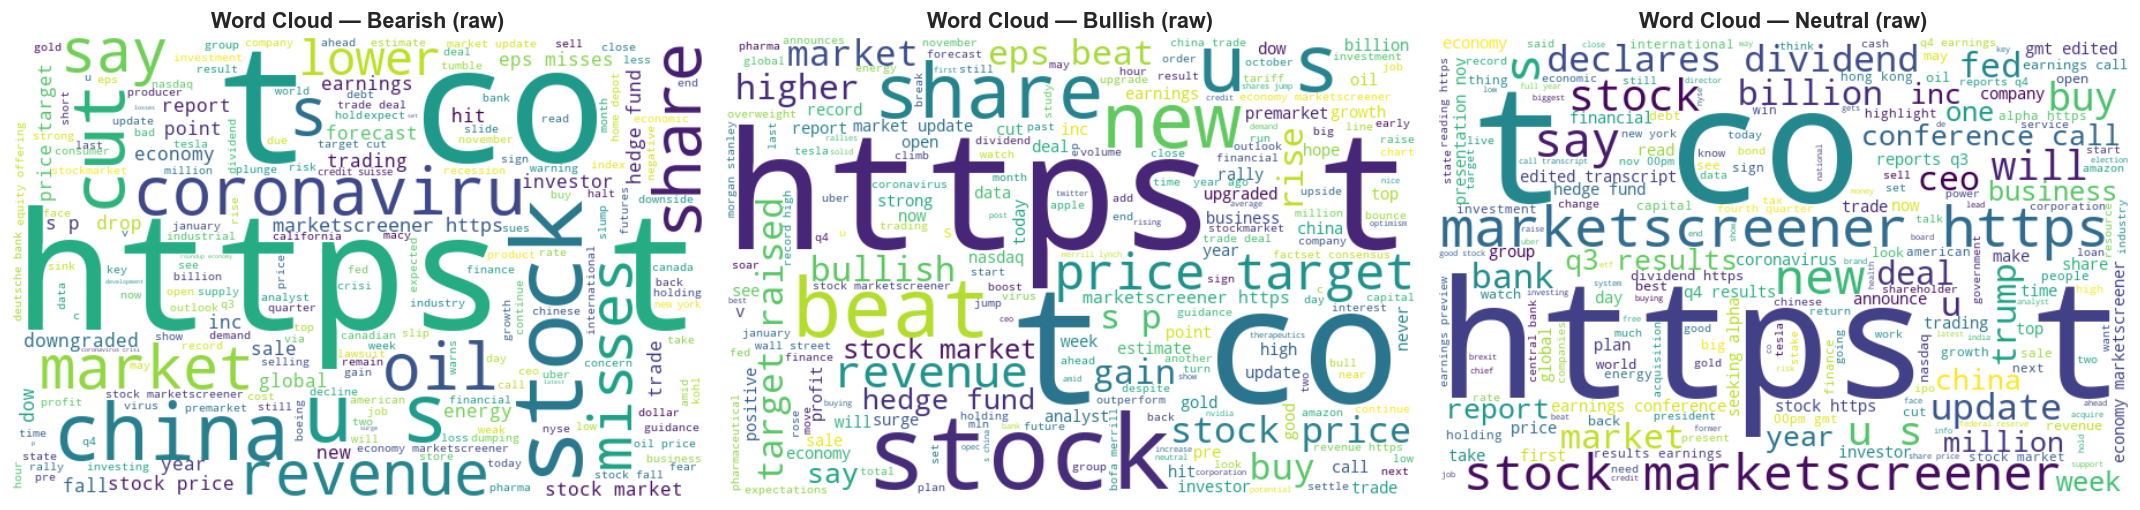

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label_id, label_name) in zip(axes, [(0,'Bearish'), (1,'Bullish'), (2,'Neutral')]):
    text = ' '.join(train[train['label'] == label_id]['text'].fillna('')).lower()
    wc = WordCloud(width=600, height=400, background_color='white').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud — {label_name} (raw)', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

Through the word clouds for each sentiment class, we can see that:
- Bearish Tweets often contain words like "drop", "fall"
- Bullish Tweets frequently include words such as "buy", "revenue"
- Neutral Tweets have more generic words like "stock", "market"

## 5. Preprocessing

### 5.1 Language of the tweets

In [85]:
!curl -O https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin
# !pip install numpy==1.26.4

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
 28 125.1M  28 36.06M   0      0 35.79M      0   00:03   00:01   00:02 35.87M
 88 125.1M  88 111.2M   0      0 55.32M      0   00:02   00:02         55.38M
100 125.1M 100 125.1M   0      0 57.12M      0   00:02   00:02         55.38M
100 125.1M 100 125.1M   0      0 57.12M      0   00:02   00:02         55.38M
100 125.1M 100 125.1M   0      0 57.11M      0   00:02   00:02         55.38M


In [86]:
model = fasttext.load_model("lid.176.bin")

def detect_language_fasttext(text):
    try:
        text_cleaned = text.replace('\n', ' ').strip()
        prediction = model.predict(text_cleaned)[0][0]
        return prediction.replace("__label__", "")
    except:
        return "unknown"

train['language'] = train['text'].apply(detect_language_fasttext)
print(train['language'].value_counts())

language
en    9450
de      25
es      16
fr      11
it      10
ja       7
nl       6
pt       5
fi       2
zh       2
sv       2
hr       1
da       1
uz       1
cs       1
vi       1
hu       1
is       1
Name: count, dtype: int64


In [87]:
# See texts that are not english
non_english = train[train['language'] != 'en']
print(f'Non-english tweets in train dataset: {len(non_english)}')
print()
non_english[['text', 'language']].head(10)


Non-english tweets in train dataset: 93



,text,language
1414,DOMTAR CORPORATION COMMUNIQUE LES RÉSULTATS PR...,es
1439,E-Porsche auf Eispiste: Das Rennsport-Comeback...,de
1449,Eudonet annonce un chiffre d’affaires récurren...,fr
1578,Ilkka-Yhtymä Oyj: Johdon liiketoimet #Stock #M...,fi
1831,Resumen: SFL publica los resultados de 2019,es
1837,Rio Tinto’s Giant Mongolia Project Dealt Anoth...,fr
1839,RoboSense erhält Zertifizierung nach IATF 16949,de
1853,Samenvatting: Japanse NEDO en Panasonic behale...,nl
1858,SASA聚酯选用英威达PTA技术,zh
1866,SFL publiceert recordresultaten voor 2019,nl


In [88]:
test['language'] = test['text'].apply(detect_language_fasttext)
# See texts that are not english
non_english = test[test['language'] != 'en']
print(f'Non-english tweets in test datset: {len(non_english)}')


Non-english tweets in test datset: 17


There are 93 non-English tweets in the train dataset and 17 in the 
test dataset. There are two options to handle them:

- **Remove them**: simple and safe, but we lose 93 training examples;
- **Translate them to English**: preserves all data, but translation can introduce noise and may not perfectly capture financial terminology.

The choice also depends on the model we will use downstream. 

**Our choice:** We will translate all them to english.

In [89]:
SUPPORTED_LANGS = ['en', 'fr', 'es', 'de', 'it', 'nl', 'ru', 'zh', 'ja', 'ar', 'fi', 'hu', 'vi', 'sv', 'cs', 'da', 'is']
loaded_models = {}

def load_translation_model(src_lang):
    model_name = f'Helsinki-NLP/opus-mt-{src_lang}-en'
    if model_name not in loaded_models:
        tokenizer = MarianTokenizer.from_pretrained(model_name)
        model = MarianMTModel.from_pretrained(model_name)
        loaded_models[model_name] = (tokenizer, model)
    return loaded_models[model_name]

def translate_text(text, src_lang):
    if src_lang == 'en' or src_lang not in SUPPORTED_LANGS:
        return text  
    try:
        tokenizer, model = load_translation_model(src_lang)
        batch = tokenizer([text], return_tensors="pt", padding=True, truncation=True)
        generated = model.generate(**batch)
        translated = tokenizer.decode(generated[0], skip_special_tokens=True)
        return translated
    except Exception as e:
        print(f"Error translating ({src_lang}): {e}")
        return text

train['translated_text'] = [
    translate_text(text, lang)
    for text, lang in tqdm(zip(train['text'], train['language']), total=len(train))]


# to see it its translating well:
train[train['language'] == 'fr']

  0%|          | 0/9543 [00:00<?, ?it/s]

c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

,text,label,sentiment,word_count,char_count,has_ticker,has_hashtag,has_url,language,translated_text
1449,Eudonet annonce un chiffre d’affaires récurren...,2,Neutral,13,82,False,False,False,fr,Eudonet announces a 32% increase in recurring ...
1837,Rio Tinto’s Giant Mongolia Project Dealt Anoth...,2,Neutral,8,53,False,False,False,fr,Rio Tinto的s Giant Mongolia Project Dealt Anoth...
1962,Tinyclues accélère sa croissance en 2019,2,Neutral,6,40,False,False,False,fr,Tinyclues accelerates its growth in 2019
4318,Cloudia lance la dernière génération de soluti...,2,Neutral,13,93,False,False,False,fr,Cloudia launches the latest generation of Proc...
4785,Korian s’associe à Omedys pour développer le p...,2,Neutral,16,114,False,False,False,fr,Korian is partnering with Omedys to develop th...
5352,Total : Résultats du quatrième trimestre et de...,2,Neutral,10,59,False,False,False,fr,Total: Results for the fourth quarter and the ...
5499,Will China Declare Force Majeure If Virus Situ...,2,Neutral,9,60,False,False,False,fr,Will China Declare Force Major If Virus Situat...
8448,DFND,2,Neutral,1,4,False,False,False,fr,DFND
8590,HOML,2,Neutral,1,4,False,False,False,fr,HOML
8707,Is Les Hôtels de Paris (EPA:HDP) Using Too Muc...,2,Neutral,10,53,False,False,False,fr,Is Hotels in Paris (EPA:HDP) Using Too Much Debt?


### 5.2 Text Cleaning

#### 5.2.1 Stop words

In [90]:
stop_words= set(stopwords.words('english'))

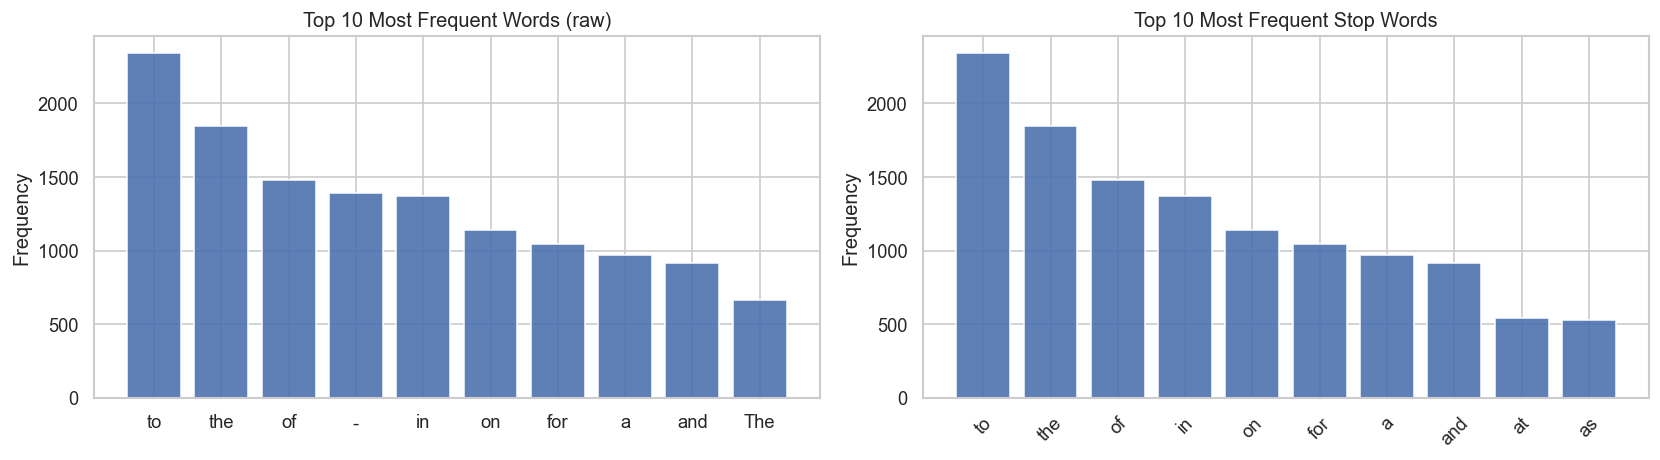


There is in total 116250 words in the train dataset
17.04% are stop words


In [91]:
train['word_count'] = train['translated_text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))


all_words = ' '.join(train['translated_text'].fillna('')).split()
freq      = pd.Series(all_words).value_counts()
top10     = freq.head(10)
axes[0].bar(top10.index, top10.values, alpha=0.9)
axes[0].set_title('Top 10 Most Frequent Words (raw)')
axes[0].set_ylabel('Frequency')

freq_sw      = pd.Series([w for w in all_words if w in stop_words]).value_counts()
top10_sw     = freq_sw.head(10)
axes[1].bar(top10_sw.index, top10_sw.values, alpha=0.9)
axes[1].set_title('Top 10 Most Frequent Stop Words')
axes[1].set_ylabel('Frequency')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print()


freq_sw.sort_values(ascending=False)[0:10]
print(f'There is in total {sum(freq)} words in the train dataset\n{sum(freq_sw)/sum(freq)*100:.2f}% are stop words')



#### 5.2.2 Punctuation 

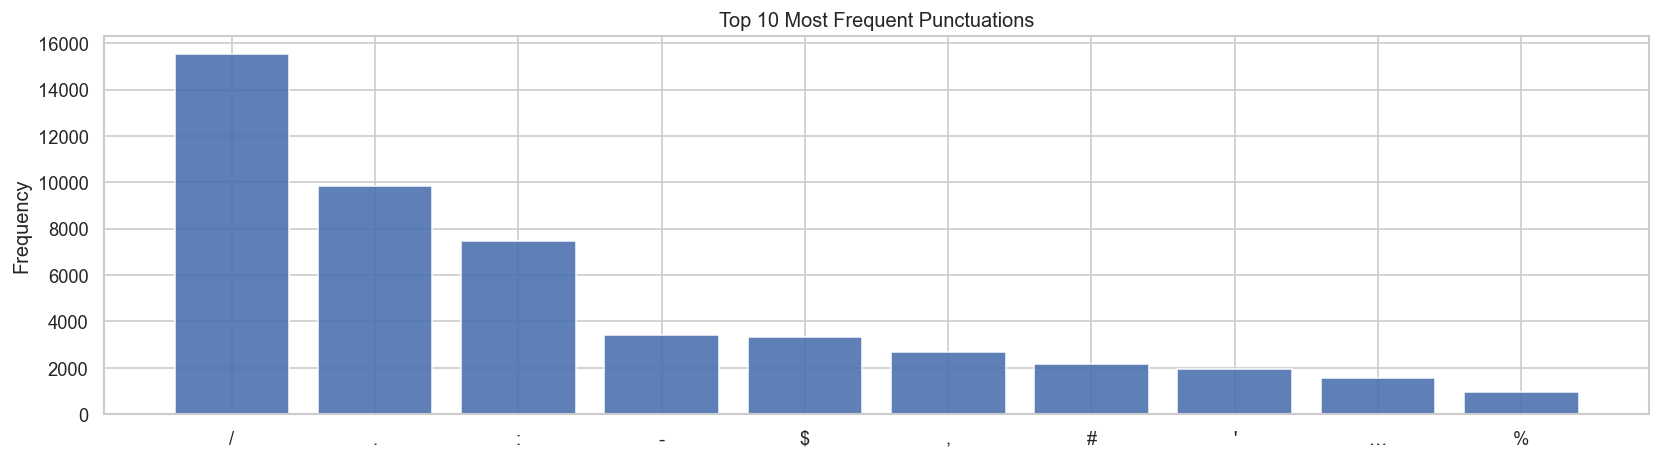


Most Frequent Punctuation 


/    15524
.     9848
:     7472
-     3395
$     3310
,     2685
#     2182
'     1949
…     1572
%      944
Name: count, dtype: int64

In [92]:
fig, axes = plt.subplots(1, 1, figsize=(14, 4))

all_punct = re.findall(r'[^\w\s]', ' '.join(train['translated_text'].fillna('')))
freq_punct      = pd.Series(all_punct).value_counts()
top10     = freq_punct.head(10)
axes.bar(top10.index, top10.values, alpha=0.9)
axes.set_title('Top 10 Most Frequent Punctuations')
axes.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print()
print('Most Frequent Punctuation ')

freq_punct.sort_values(ascending=False)[0:10]


Emojis may be important also to determine the sentiment of the tweet

In [93]:
all_emoji = [c for c in ' '.join(train['translated_text'].fillna('')) if c in emoji.EMOJI_DATA]
freq_emoji = pd.Series(all_emoji).value_counts()
top10      = freq_emoji.head(10)

has_emoji = train['translated_text'].apply(lambda x: any(c in emoji.EMOJI_DATA for c in str(x)))

print(f'There are in total {sum(freq_emoji)} emojis')
print('Most Frequent Emojis:')
freq_emoji.sort_values(ascending=False)[0:60]

There are in total 60 emojis
Most Frequent Emojis:


®    9
⚡    4
©    3
▶    3
✅    3
📈    2
™    2
👀    2
▪    2
🔔    2
🤔    1
♀    1
😳    1
👍    1
🌴    1
☀    1
🎄    1
⚧    1
🏫    1
❄    1
🌍    1
🥑    1
🎶    1
⬆    1
🐢    1
🎤    1
😀    1
🔄    1
🌏    1
😷    1
📱    1
♻    1
🏞    1
🏎    1
🎧    1
📰    1
➡    1
👋    1
Name: count, dtype: int64

In [94]:
for label_id, label_name in {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}.items():
    subset = train[(train['label'] == label_id) & has_emoji]
    print(f'\n{label_name}: {len(subset)} tweets with emojis')
    


Bearish: 0 tweets with emojis

Bullish: 3 tweets with emojis

Neutral: 47 tweets with emojis


#### 5.2.3 Dates

In [95]:
dates = re.findall(r'\d{2,4}[-/_.]\d{2}[-/_.]\d{2,4}', ' '.join(train['translated_text'].fillna('')))
freq_dates      = pd.Series(dates).value_counts()
top10     = freq_dates.head(10)


print(f'There are {sum(freq_dates)} dates in the dataset\n')

print('Most Frequent Dates')

freq_dates.sort_values(ascending=False)[0:10]

There are 22 dates in the dataset

Most Frequent Dates


11/25/19      2
15/12/19      2
12/17/2019    2
22/11/2019    1
25.11.2019    1
31/10/19      1
12/15/2019    1
11-25-19      1
12/13/19      1
12/16/2019    1
Name: count, dtype: int64

#### 5.2.4 Words in capslock

In [96]:
all_caps = re.findall(r'\b[A-Z]{2,}\b', ' '.join(train['translated_text'].fillna('')))
freq_caps      = pd.Series(all_caps).value_counts()

print(f'There are {sum(freq_caps)} words in capslock in the dataset\n')

print('Most Frequent Caps Words - Word Count:')

freq_caps.sort_values(ascending=False)[0:20]


There are 6915 words in capslock in the dataset

Most Frequent Caps Words - Word Count:


EPS       188
CEO       178
NASDAQ    116
NYSE      109
GMT        89
US         85
OPEC       47
IPO        44
UPDATE     41
EU         39
USD        34
UK         34
WTI        33
CFO        33
TSE        29
FDA        27
LVMH       27
SPY        27
ETF        26
AT         26
Name: count, dtype: int64

#### 5.2.5 Hours

In [97]:
# Extract hours/times from text
hours = re.findall(
    r'\b(?:[01]?\d|2[0-3])[:h][0-5]\d(?:\s?[AaPp][Mm])?|\b(?:1[0-2]|0?\d)\s?[AaPp][Mm]\b',
    ' '.join(train['translated_text'].fillna(''))
)

# Frequency count
freq_hours = pd.Series(hours).value_counts()

# Top 10 most common
top10_hours = freq_hours.head(10)

print(f'There are {sum(freq_hours)} time expressions in the dataset\n')

print('Most Frequent Hours')
print(top10_hours)

There are 99 time expressions in the dataset

Most Frequent Hours
1:00pm     12
3:00pm     11
9:30pm     11
1:30pm      8
4:00pm      7
2:00pm      6
10:00pm     6
5:00pm      4
7:00pm      3
4:30pm      3
Name: count, dtype: int64


#### 5.2.6 Numbers

In [98]:
def show_number_context(texts, number, window=5, n_examples=10):

    examples = []
    for text in texts:
        # Skip missing values
        if pd.isna(text):
            continue
        words = str(text).split()

        for i, word in enumerate(words):
            if re.fullmatch(r'\d+', word) and word == str(number):

                start = max(0, i - window)
                end = min(len(words), i + window + 1)

                context = ' '.join(words[start:end])

                examples.append(context)

                if len(examples) >= n_examples:
                    return examples

    return examples


In [99]:
for ctx in show_number_context(train["translated_text"], 8):
    print(ctx)
    print()

Magyar Nemzeti Bank effective from 8 April 2020 #economy #MarketScreener… https://t.co/LtgoxFiEBO

10 additional Boeing 737 MAX 8 planes, valued at $1.2 bln

8 Sources of Income Social Security's

The 8 steps I took to make

S&P 500 down by about 8 points, 0.2%, at the open

0.3%; S&P 500 futures rise 8 points, or 0.2%

block a House subpoena for 8 years of his financial records

Feb 12 P $FTCH Jul 8 P $IBN Mar 14… https://t.co/Jxoi16iCyi

$IWM back above 8 EMA. Closing matters.. https://t.co/1aDgHnJKPx

8 Cannabis Stocks With Wall Street



This context analysis of numerical tokens shows that numbers frequently appear in financially relevant expressions such as percentages, stock market indices (e.g., S&P 500), technical indicators (e.g., 8 EMA), quantities, and company-related figures. Therefore, numbers will be retained during preprocessing, as removing them could result in the loss of potentially useful sentiment information.  

Also, numerical information often appears in factual market reports and company announcements, which may help distinguish Neutral tweets from more opinion-oriented Bearish or Bullish content.

Let's just check the unique numbers that we have.

In [100]:
def count_number_contexts(texts, numbers):
    counts = {}
    for number in numbers:
        count = 0
        for text in texts:
            if pd.isna(text):
                continue
            words = str(text).split()
            for word in words:
                if re.fullmatch(r'\d+', word) and word == str(number):
                    count += 1
        counts[number] = count
    
    for number, count in sorted(counts.items(), key=lambda x: x[1], reverse=True):
        print(f"{str(number):>10} → {count} occurrences")


In [101]:
from collections import Counter

number_counts = Counter()
for text in train["translated_text"]:
    if pd.isna(text):
        continue
    for word in str(text).split():
        if re.fullmatch(r'\d+', word):
            number_counts[word] += 1
count_number_contexts(train["translated_text"], number_counts.keys())


      2019 → 256 occurrences
      2020 → 222 occurrences
         3 → 85 occurrences
       500 → 71 occurrences
         5 → 48 occurrences
         1 → 35 occurrences
         2 → 34 occurrences
       737 → 34 occurrences
        10 → 34 occurrences
         4 → 29 occurrences
         6 → 22 occurrences
        15 → 21 occurrences
         7 → 20 occurrences
         8 → 12 occurrences
        12 → 11 occurrences
        25 → 11 occurrences
        30 → 11 occurrences
      2018 → 11 occurrences
        50 → 11 occurrences
         9 → 11 occurrences
       100 → 10 occurrences
        11 → 9 occurrences
        20 → 8 occurrences
        16 → 8 occurrences
      2021 → 8 occurrences
      2016 → 7 occurrences
        13 → 7 occurrences
       400 → 6 occurrences
      2025 → 6 occurrences
        22 → 6 occurrences
        19 → 6 occurrences
      2017 → 6 occurrences
        99 → 5 occurrences
        35 → 5 occurrences
        21 → 5 occurrences
        24 → 4 occurrences
     

We have a lot of possible datas (e.g. 2018) so we sill focus only of these ones for now.

In [102]:
years = [2019, 2020, 2018, 2021, 2016, 2025, 2017, 2000, 2011, 2008, 2026, 2014, 2027, 2001, 1993, 2050, 2030, 2023, 2045, 1999, 2028, 1918, 1893, 1787, 1998, 2003, 2010, 2009]

for number in years:
    print(f"\n {number} ")
    for ctx in show_number_context(train["translated_text"], number):
        print(ctx)
        print()


 2019 
Upgrades, Downgrades For December 17, 2019

Upgrades, Downgrades For November 25, 2019

Repo Auction Announcement -25 November 2019 #Parkmead #Stock #MarketScreener… https://t.co/cMHuPB7ZFM

in first eleven months of 2019 #Airbus #Stock #MarketScreener… https://t.co/5Ux2IqpCAP

in first eleven months of 2019 https://t.co/aNHnf3f89F https://t.co/LHeC37Q814

a Strong Second Half Of 2019

Medical Properties Trust, Inc. Completes 2019 With Record $4.5 Billion in

Tinyclues Announces Major Growth in 2019

53% higher than the estimated 2019 figure... https://t.co/20Fue6Os6N

$454M; lowers FFO guidance for 2019 https://t.co/M3AcW52osx


 2020 
$MU $WDC - Bull sees 2020 upsides for MU, WDC https://t.co/65zGfs82xI

The Top Telecom Pick For 2020

Bull sees 2020 upsides for MU, WDC

upgrades Nvidia to buy, predicting 2020 will be 'a return to

S&P 500 Gaining 10% in 2020

to have economic downturn in 2020

into the second quarter of 2020 to m… https://t.co/b1GHWeY0dy

Repo Auction Results

#### **Conclusion**


- For **stopwords**, since removing them in sentimental analysys is a grey area, as words like "not", "but", and "however" can reverse the sentiment of a sentence, we will keep them . 
- Like said before the **url** don't give any new information of the sentiment of the tweet so it will be removed;
- For **punctiontion**, according to our project goal pucntions like ``!``,``?``, and ``emojis`` express emotions, and numerical symbols like ``$``,``£``,``%``,``.`` are important. Symbols like `@`, ``"``, ``()``, ``---``, ``...``, ``*``, most likley are noise. So we will not remove the numerical nor the punctionation that express emotion;
- For **dates** since there are only 22 of them in the dataset and they don't carry any sentiment, they will remove them. While analysing numbers we saw that we have some dates as "24 November 2019" and they will be removed as well; 
- For **numbers**, they can represent the amount of money loss in the stock market meaning it's a necessary info. Some of them were years and these were removed since they did not had any information after see their context, while others, such as financial crisis 2008, were kept since they represent events;
- For **casing**, we will lowercase all words to normalize the text, ensuring that the same word in different cases (e.g. "USD", "Usd", "usd") is treated as a single token. Although all-caps words can carry sentiment signal in tweets, we accept this tradeoff for consistency. **Lemmatization** further reduces different forms of the same word (e.g. "trading", "traded", "trade") to a single base form.
- For **hours**, no significant insight was obtained, as time expressions are unlikely to contribute to sentiment classification.

Application of a formula that will:

1. Put everything in lowercase
2. Remove the url links
3. Remove noisy characters - keeping the numerical punctiation and the emojis
4. Remove dates and years that are not events
5. Remove hours
6. Lematize



In [103]:
# Snowball stemmer to reduce words to their root form
stemmer = SnowballStemmer('english')

# WordNet lemmatizer to convert words to their base or dictionary form
lemma = WordNetLemmatizer()


def clean(text_list,stopwords=True, lemmatize=True, stem=False):
    """
    Clean a list of text strings:
      - lowercase
      - remove non-letter characters (punctuation, URLs)
      - optionally lemmatize or stem
      - remove dates and times
      - remove standalone numbers (but preserve important ones like "Russell 2000")
    """
    clean_text = []
    for text in tqdm(text_list):
        text = str(text).lower()
        text = re.sub(r'https?://\S+', '', text)                        # remove URLs
        text = re.sub('br', '', text)                              # remove HTML <br>

        text = re.sub(r'\brussell\s+2000\b', 'russell2000', text)       # preserve Russell 2000 

        # formalize important events
        text = re.sub(r'financial crisis.*2008|2008.*financial crisis|crisis.*2008',
                      'financial_crisis_2008', text)
        text = re.sub(r'dot[- ]?com bubble', 'dotcom_bubble_2000', text)
        text = re.sub(r'covid[- ]?19(?:\s?(crash|pandemic|crisis))?',
                      'covid19_event', text)

        emojis = ''.join(c for c in text if c in emoji.EMOJI_DATA) # extract emojis before cleaning   

        text= re.sub(r'\d{2,4}[-/_.]\d{2}[-/_.]\d{2,4}', '', text) # remove dates
        # remove datas such as "12 Jan 2020" or "3 March 2019"
        text = re.sub(
        r'\b\d{1,2}\s+(?:jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec|'
        r'january|february|march|april|may|june|july|august|september|october|november|december)\s+\d{2,4}\b',
        '', text, flags=re.IGNORECASE)

        text = re.sub(r'\b(19|20)\d{2}\b', '', text)                    # remove years  

        text = re.sub(r'\b(?:[01]?\d|2[0-3])[:h][0-5]\d(?:\s?[AaPp][Mm])?|\b(?:1[0-2]|0?\d)\s?[AaPp][Mm]\b', '', text) # remove time expressions

        text = re.sub(r'[^\w\s!?.,\$%€£]', ' ', text)              # clean text but keep important punctuation

        text = text + ' ' + emojis                                 # add emojis back at the end
    
        

        if stopwords:
            text = " ".join([word for word in text.split() if word not in stop_words])
        # Lemmatize
        if lemmatize:
            text = ' '.join(lemma.lemmatize(word) for word in text.split())
        # Stemming
        if stem:
            text = ' '.join(stemmer.stem(word) for word in text.split())
        clean_text.append(text)
    
    return clean_text


# Apply cleaning function
train['clean_text'] = clean(train['translated_text'], stopwords=False, lemmatize=True, stem=False)
#FLAG
train['clean_text_no_sw'] = clean(train['translated_text'], stopwords=True, lemmatize=True, stem=False)
# View original and cleaned texts
train[['text', 'clean_text', 'clean_text_no_sw']].head()

  0%|          | 0/9543 [00:00<?, ?it/s]

  0%|          | 0/9543 [00:00<?, ?it/s]

,text,clean_text,clean_text_no_sw
0,$BYND - JPMorgan reels in expectations on Beyo...,$bynd jpmorgan reel in expectation on beyond meat,$bynd jpmorgan reel expectation beyond meat
1,$CCL $RCL - Nomura points to bookings weakness...,$ccl $rcl nomura point to booking weakness at ...,$ccl $rcl nomura point booking weakness carniv...
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...","$cx cemex cut at credit suisse, j.p. morgan on...","$cx cemex cut credit suisse, j.p. morgan weak ..."
3,$ESS: BTIG Research cuts to Neutral https://t....,$ess btig research cut to neutral,$ess btig research cut neutral
4,$FNKO - Funko slides after Piper Jaffray PT cu...,$fnko funko slide after piper jaffray pt cut,$fnko funko slide piper jaffray pt cut


## 6. Corpus Split

To start our modeling phase we will split the train.csv data to a train and validation sets, where 80% will be used for training and 20% for validation.<br>
We will use two versions of the data depending on the model:
- **Cleaned text** (clean_text): with all the preprocessing steps appliedthroughout this notebook (lowercasing, URL removal, lemmatization, etc.),used for traditional models such as Logistic Regression and KNN;
- **Raw text** (text): the original untouched version of the dataset, used for pre-trained transformer models such as BERT and RoBERTa, since these models have their own internal tokenizer and were already pretrained on natural text.

In [104]:
# Split for models with cleaned text 
X_train = train['clean_text']
y_train = train['label'] 

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=2)

In [105]:
# Split for models with raw text (for PRE-TRAINED MODELS)
X_raw = train['text']
y_raw = train['label'] 
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=2)

In [106]:
# Split for models with cleaned text without stop words
X_train_no_sw = train['clean_text_no_sw']
y_train_no_sw = train['label'] 

X_train_no_sw, X_val_no_sw, y_train_no_sw, y_val_no_sw = train_test_split(X_train_no_sw, y_train_no_sw, test_size=0.2, stratify=y_train_no_sw, random_state=2)

## 7. Feature Engineering

### 7.1 Bag of Words (BoW) Features

Each unique word in the corpus becomes a feature. A document is represented as a binary vector indicating which vocabulary words it contains (`binary=True`).

**Vocabulary** = the set of all words seen in the training corpus.  
**Document vector** = a binary indicator over the full vocabulary.

We experiment BoW with two variations:
#### **1. CountVectorizer**
Each position in the vector contains the **raw count** of how many times that word appears in the tweet.

#### **2. TF-IDF (Term Frequency: Inverse Document Frequency)**
Instead of raw counts, each position contains a **weight** based on two factors:
- **TF**: how often the word appears in that tweet
- **IDF**: how rare the word is across all tweets

Both produce a sparse matrix of shape (n_tweets*5000) where most values are zero since each tweet only contains a tiny fraction of the full vocabulary.

In [107]:
def bow_or_tfidf(texts, method='bow', max_features=5000):
    """
    Convert a list of text documents into a numerical feature matrix using either
    Bag of Words (BoW) or TF-IDF vectorization.

    Parameters:
        texts (list or pandas Series): Collection of text documents to vectorize.
        method (str): 'bow' for CountVectorizer or 'tfidf' for TF-IDF. Default is 'bow'.
        max_features (int): Maximum number of features (vocabulary size). Default is 5000.

    Returns:
        X (scipy sparse matrix): The document-term matrix.
        vectorizer: The fitted vectorizer instance.

    Raises:
        ValueError: If the provided method is not 'bow' or 'tfidf'.
    """
    if method == 'bow':
        vectorizer = CountVectorizer(max_features=max_features)
    elif method == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=max_features)
    else:
        raise ValueError("Choose a valid method: 'bow' or 'tfidf'.")

    X = vectorizer.fit_transform(texts)
    return X, vectorizer

#### 7.1.1 CountVectorizer


In [108]:
X_train_bow, bow_vectorizer = bow_or_tfidf(X_train, method='bow')
X_val_bow = bow_vectorizer.transform(X_val)

print(f'Documents  (rows)   : {X_train_bow.shape[0]:,}')
print(f'Vocabulary (columns): {X_train_bow.shape[1]:,}')
print(f'Non-zero entries    : {X_train_bow.nnz:,}')

density = X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]) * 100
print(f'Matrix density      : {density:.4f}%  <- almost all zeros (sparse matrix)')

Documents  (rows)   : 7,634
Vocabulary (columns): 5,000
Non-zero entries    : 73,502
Matrix density      : 0.1926%  <- almost all zeros (sparse matrix)


In [109]:
print('BoW vectors for documents 10-12:')
print(X_train_bow[10:13].toarray())

print('\nSample vocabulary terms (positions 0-20):')
print(bow_vectorizer.get_feature_names_out()[0:20])

BoW vectors for documents 10-12:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Sample vocabulary terms (positions 0-20):
['00' '000' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '100' '1000'
 '100m' '105' '108' '11' '12' '120']


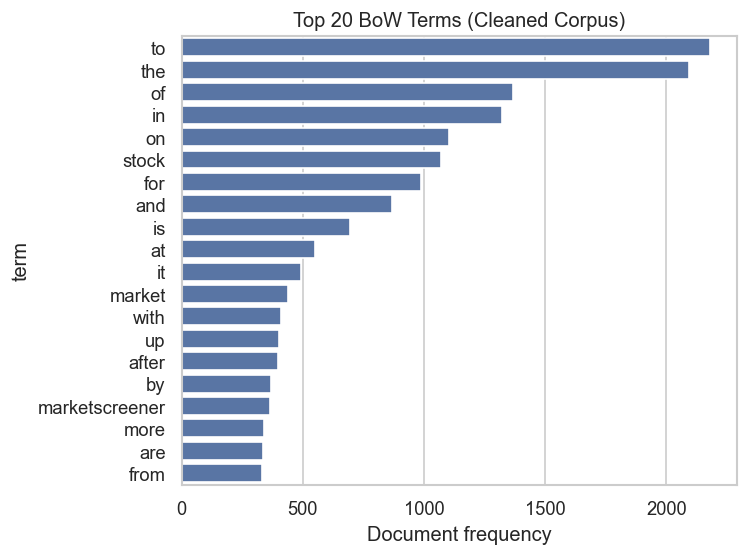

In [110]:
bow_sum   = np.array(X_train_bow.sum(axis=0)).flatten()
bow_terms = bow_vectorizer.get_feature_names_out()
top20     = pd.DataFrame({'term': bow_terms, 'count': bow_sum}).sort_values('count', ascending=False).head(20)

sns.barplot(data=top20, x='count', y='term')
plt.title('Top 20 BoW Terms (Cleaned Corpus)')
plt.xlabel('Document frequency')
plt.tight_layout()
plt.show()

In [111]:
X_train_bow_no_sw, bow_vectorizer = bow_or_tfidf(X_train_no_sw, method='bow')
X_val_bow_no_sw = bow_vectorizer.transform(X_val_no_sw)

#### 7.1.2 TF-IDF

TF-IDF (Term Frequency - Inverse Document Frequency) is an improvement over simple BoW counting and is considered a variation of BoW.

In [112]:
X_train_tfidf, tfidf_vectorizer = bow_or_tfidf(X_train, method='tfidf')
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# Shape
print(f'Documents  (rows)   : {X_train_tfidf.shape[0]:,}')
print(f'Vocabulary (columns): {X_train_tfidf.shape[1]:,}')

# Show TF-IDF weights for the first tweet
first_tweet = X_train.iloc[0]
first_vec   = X_train_tfidf[0]
tfidf_terms = tfidf_vectorizer.get_feature_names_out()
nonzero_idx = first_vec.nonzero()[1]

print(f'\nOriginal tweet : {first_tweet}')
print('TF-IDF weights :')
for i in nonzero_idx:
    print(f'  {tfidf_terms[i]:<20} {first_vec[0, i]:.4f}')


Documents  (rows)   : 7,634
Vocabulary (columns): 5,000

Original tweet : home depot fall sharply after release of 3rd quarter result
TF-IDF weights :
  home                 0.3148
  depot                0.3681
  fall                 0.3038
  sharply              0.4077
  after                0.2111
  release              0.3763
  of                   0.1500
  3rd                  0.4077
  quarter              0.2843
  result               0.2262


In [113]:
# Show the full vector for the first tweet
print(f'\nFull TF-IDF vector for tweet 0 (first 20 values):')
print(X_train_tfidf[0].toarray()[0][:20].round(4))

print(f'\nVector shape : {X_train_tfidf[0].toarray().shape}')
print(f'Non-zero positions : {first_vec.nnz} out of {X_train_tfidf.shape[1]}')

# Show side by side: word → position → weight
print(f'\nWord → Position → TF-IDF weight:')
for i in nonzero_idx:
    print(f'  {tfidf_terms[i]:<20} position {i:<6} weight: {first_vec[0, i]:.4f}')


Full TF-IDF vector for tweet 0 (first 20 values):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Vector shape : (1, 5000)
Non-zero positions : 10 out of 5000

Word → Position → TF-IDF weight:
  home                 position 2034   weight: 0.3148
  depot                position 1314   weight: 0.3681
  fall                 position 1612   weight: 0.3038
  sharply              position 4007   weight: 0.4077
  after                position 265    weight: 0.2111
  release              position 3620   weight: 0.3763
  of                   position 3144   weight: 0.1500
  3rd                  position 72     weight: 0.4077
  quarter              position 3508   weight: 0.2843
  result               position 3700   weight: 0.2262


In [114]:
X_train_tfidf_no_sw, tfidf_vectorizer = bow_or_tfidf(X_train_no_sw, method='tfidf')
X_val_tfidf_no_sw = tfidf_vectorizer.transform(X_val_no_sw)

### 7.2 Word2Vec

Unlike BoW, **Word2Vec** learns the **meaning** of words by looking at the context they appear in, meaning that words that appear in similar contexts get similar vectors.

Each word becomes a **dense vector of 100 numbers**. Since we need one vector per tweet, we **average all word vectors** in the tweet into a single vector.

Two variations of Word2Vec were implemented:

| | Skip-Gram | CBOW |
|---|---|---|
| Input | center word | context words |
| Predicts | context words | center word |
| Better for | rare words | frequent words |
| Speed | slower | faster |


### 7.3 GloVe

Unlike Word2Vec, **GloVe** (Global Vectors) does not use a neural network. Instead, it builds a global word co-occurrence matrix from the entire corpus and factorizes it to produce word embeddings...

In [115]:
# Train Word2Vec on training data only
tokenized_train = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,  # each word becomes a vector of 100 numbers
    window=2,         # context window size
    min_count=1,      # minimum word frequency to be included
    sg=1              # 1 = Skip-gram, 0 = CBOW
)

word_vectors = w2v_model.wv
print(f'Vocabulary size : {len(word_vectors.index_to_key)}')
print(f'Vector size     : {w2v_model.vector_size}')

# Helper function: average word vectors into one document vector
def get_doc_embedding(doc, word_vectors, dim=100):
    tokens = doc.split()
    vectors = [word_vectors[word] for word in tokens if word in word_vectors.index_to_key]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(dim)

# Generate embeddings
X_train_w2v = np.vstack([get_doc_embedding(doc, word_vectors) for doc in X_train])
X_val_w2v   = np.vstack([get_doc_embedding(doc, word_vectors) for doc in X_val])

print(f'\nX_train_w2v shape : {X_train_w2v.shape}')  # (n_tweets, 100)
print(f'X_val_w2v shape   : {X_val_w2v.shape}')

# Sanity check: similar words to 'stock'
print('\nWords most similar to "stock":')
print(w2v_model.wv.most_similar('stock', topn=5))

Vocabulary size : 15525
Vector size     : 100

X_train_w2v shape : (7634, 100)
X_val_w2v shape   : (1909, 100)

Words most similar to "stock":
[('economy', 0.9788458347320557), ('matprem', 0.8994067311286926), ('wti', 0.893708348274231), ('mcdonalds', 0.8922767043113708), ('investing', 0.8912383317947388)]


In [116]:
example_tweet = X_train.iloc[0]
example_vec   = get_doc_embedding(example_tweet, word_vectors)

print(f'\nOriginal tweet : {example_tweet}')
print(f'Embedding shape: {example_vec.shape}')
print(f'First 10 values: {example_vec[:10].round(4)}')


Original tweet : home depot fall sharply after release of 3rd quarter result
Embedding shape: (100,)
First 10 values: [-0.2008  0.3147 -0.0529  0.0975  0.061  -0.3239  0.2047  0.5236 -0.2911
 -0.1803]


In [117]:
# Now for dataset without stop words
X_train_w2v_no_sw = np.vstack([get_doc_embedding(doc, word_vectors) for doc in X_train_no_sw])
X_val_w2v_no_sw   = np.vstack([get_doc_embedding(doc, word_vectors) for doc in X_val_no_sw])

#### 7.2.2 CBOW (Continuous Bag of Words)

**CBOW** is the second training approach of Word2Vec. While Skip-gram predicts the surrounding context words given a center word, CBOW does the opposite.

In [118]:
w2v_model_cbow = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=2,
    min_count=1,
    sg=0              # 0 = CBOW
)

word_vectors_cbow = w2v_model_cbow.wv

# Generate embeddings
X_train_w2v_cbow = np.vstack([get_doc_embedding(doc, word_vectors_cbow) for doc in X_train])
X_val_w2v_cbow   = np.vstack([get_doc_embedding(doc, word_vectors_cbow) for doc in X_val])

print(f'Vocabulary size        : {len(word_vectors_cbow.index_to_key)}')
print(f'X_train_w2v_cbow shape : {X_train_w2v_cbow.shape}')
print(f'X_val_w2v_cbow shape   : {X_val_w2v_cbow.shape}')

# Sanity check — compare with Skip-gram results
print('\nWords most similar to "stock" (CBOW):')
for word, score in w2v_model_cbow.wv.most_similar('stock', topn=5):
    print(f'  {word:<20} similarity: {score:.4f}')

Vocabulary size        : 15525
X_train_w2v_cbow shape : (7634, 100)
X_val_w2v_cbow shape   : (1909, 100)

Words most similar to "stock" (CBOW):
  economy              similarity: 0.9983
  wti                  similarity: 0.9849
  roundup              similarity: 0.9848
  investing            similarity: 0.9843
  update               similarity: 0.9834


In [119]:
# Same but without stop words
X_train_w2v_cbow_no_sw = np.vstack([get_doc_embedding(doc, word_vectors_cbow) for doc in X_train_no_sw])
X_val_w2v_cbow_no_sw   = np.vstack([get_doc_embedding(doc, word_vectors_cbow) for doc in X_val_no_sw])

#### 7.3 GloVe 

**GloVe** is a pre-trained word embedding model developed by Stanford.
Unlike Word2Vec which learns from local context windows, GloVe learns from **how often words appear together** across the entire corpus.

In [120]:
model_name = 'glove-twitter'
emb_size = 100

w2v = gensim.downloader.load(f'{model_name}-{emb_size}')

def corpus2vec(corpus, w2v):
    """
    Convert a list of text documents into lists of word vectors using a pre-trained GloVe model.

    Parameters:
    corpus (list): List of strings, each representing a document (e.g., tweet).
    w2v (gensim KeyedVectors): Pre-trained word vectors loaded via gensim.

    Returns:
    list: A list where each element is a list of word vectors corresponding to the words in a document.
    """
    index_set = set(w2v.index_to_key)  # For fast lookup
    word_vec = w2v.get_vector          # Shortcut for faster access
    return [
        [word_vec(word) for word in doc.split() if word in index_set]
        for doc in tqdm(corpus)
    ]

# Apply to training and validation data
x_train_vec = corpus2vec(X_train, w2v)
x_val_vec = corpus2vec(X_val, w2v)

# Function to convert each tweet into a single vector (average of its word vectors)
def average_vectors(vector_list, dim):
    """
    Compute the average vector for a list of word vectors.
    If the list is empty, return a zero vector.

    Parameters:
    vector_list (list): List of word vectors (e.g., from a tweet).
    dim (int): Dimensionality of the embeddings.

    Returns:
    numpy.ndarray: Averaged vector representation of the input list.
    """
    return np.mean(vector_list, axis=0) if vector_list else np.zeros(dim)

# Generate averaged document embeddings for training and validation sets
X_train_glove_avg = np.vstack([average_vectors(vecs, emb_size) for vecs in x_train_vec])
X_val_glove_avg = np.vstack([average_vectors(vecs, emb_size) for vecs in x_val_vec])

  0%|          | 0/7634 [00:00<?, ?it/s]

  0%|          | 0/1909 [00:00<?, ?it/s]

In [121]:
# Same but for dataset without stop words
x_train_vec_no_sw = corpus2vec(X_train_no_sw, w2v)
x_val_vec_no_sw = corpus2vec(X_val_no_sw, w2v)
X_train_glove_avg_no_sw = np.vstack([average_vectors(vecs, emb_size) for vecs in x_train_vec_no_sw])
X_val_glove_avg_no_sw = np.vstack([average_vectors(vecs, emb_size) for vecs in x_val_vec_no_sw])


  0%|          | 0/7634 [00:00<?, ?it/s]

  0%|          | 0/1909 [00:00<?, ?it/s]

### 7.4 **Transformer Encoders**

Transformer Encoders are deep learning architectures that generate contextual representations of text using a mechanism called self-attention. Unlike traditional methods such as BoW or Word2Vec, they consider the entire sentence when encoding each word, allowing them to capture context, semantics, and relationships between words.

**BERT (Bidirectional Encoder Representations from Transformers)** is one of the most influential Transformer Encoder models. **FinBERT** is a version of BERT further pre-trained on financial text, **RoBERTa** is an optimized variant of BERT trained with improved strategies and larger datasets and **BERTweet** is a RoBERTa-based model specifically pre-trained on Twitter data.

Both FinBERT, RoBERTa and BERTweet produce dense contextual embeddings and can be fine-tuned for sentiment classification tasks.

#### **1. FinBERT CLS (Transformer Encoder)**
FinBERT is highly suitable for financial sentiment analysis because it was specifically pre-trained on financial text. 

Each tweet is represented using the final embedding of the special `[CLS]` token, which captures the contextual meaning of the entire sentence.

The [CLS] token is a special token added at the beginning of every tweet. After passing through the Transformer Encoder, its final embedding serves as a compact representation of the entire tweet and is used for sentiment classification.

Unlike BoW or TF-IDF, FinBERT understands:
- contextual meaning
- word order
- semantic relationships
- financial terminology

The `[CLS]` embedding is passed to a classification layer that predicts:
- Bearish (0)
- Bullish (1)
- Neutral (2)

#### **2. RoBERTa (Transformer Encoder)**
Similarly to FinBERT, RoBERTa uses the final representation of the `[CLS]` token as a sentence-level embedding for classification.

RoBERTa captures:
- sentence context
- semantic meaning
- long-range dependencies
- nuanced sentiment expressions

#### **3. BERTweet (Transformer Encoder)**

BERTweet is a RoBERTa-based Transformer Encoder that was specifically pre-trained on a large corpus of English tweets. Because it was trained on social media text, it is particularly effective at understanding informal language, abbreviations, hashtags, mentions, and other Twitter-specific patterns.

Similarly to FinBERT and RoBERTa, each tweet is represented using the final embedding of the special `[CLS]` token, which captures the contextual meaning of the entire tweet.

Unlike FinBERT, which specializes in financial language, BERTweet specializes in the linguistic characteristics of Twitter data. This makes it particularly suitable for sentiment analysis tasks involving tweets.

Each tweet is converted into a dense 768-dimensional contextual embedding, which is then used as input for downstream classification models.

#### 7.4.1 FinBERT CLS


In [122]:
# 1. Load a Transformer Encoder model

checkpoint = "ProsusAI/finbert"

# Load the tokenizer associated with FinBERT:
tokenizer_finbert = AutoTokenizer.from_pretrained(checkpoint)

# Load only the transformer encoder:
finbert_model = AutoModel.from_pretrained(checkpoint)

# Auto-detect best available device (MPS on Apple Silicon, CPU otherwise)
device = "mps" if torch.backends.mps.is_available() else "cpu"

# Move the model to the selected device.
embeddings_model = finbert_model.to(device)

print(f"Using device: {device}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cpu


In [123]:
# 2. Function to generate CLS embeddings

def generate_cls_embeddings(texts, embeddings_model, tokenizer, batch_size=32, max_length=128, desc="Generating embeddings"):
    """
    Converts a list/Series of texts into Transformer Encoder CLS embeddings.

    Each tweet is passed through the Transformer Encoder.
    The first token, [CLS], is used as the sentence-level representation.

    Output:
    - A NumPy array with shape: (number_of_tweets, 768)
    """
    # Put the model in evaluation mode:
    embeddings_model.eval()
    # Empty list that will store the embeddings generated for each batch:
    all_embeddings = []

    texts = list(texts)
    # Process tweets in batches:
    for i in tqdm(range(0, len(texts), batch_size), desc=desc):

        batch_texts = texts[i:i + batch_size]
        
        # Tokenization:
        encoded_inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded_inputs = {
            key: value.to(device)
            for key, value in encoded_inputs.items()
        }

        with torch.no_grad():
            outputs = embeddings_model(**encoded_inputs)

        # Extract CLS embeddings:
        cls_embeddings = outputs.last_hidden_state[:, 0, :]

        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

In [124]:
# 3. Generate embeddings for train and validation sets

X_train_finbert = generate_cls_embeddings(
    X_train_raw,
    embeddings_model=finbert_model,
    tokenizer= tokenizer_finbert,
    batch_size=32,
    desc="Train CLS Embeddings"
)

X_val_finbert = generate_cls_embeddings(
    X_val_raw,
    embeddings_model=finbert_model,
    tokenizer=tokenizer_finbert,
    batch_size=32,
    desc="Validation CLS Embeddings"
)

y_train_finbert = np.array(y_train_raw)
y_val_finbert = np.array(y_val_raw)

print("Train embeddings shape:", X_train_finbert.shape)
print("Validation embeddings shape:", X_val_finbert.shape)

Train CLS Embeddings:   0%|          | 0/239 [00:00<?, ?it/s]

Validation CLS Embeddings:   0%|          | 0/60 [00:00<?, ?it/s]

Train embeddings shape: (7634, 768)
Validation embeddings shape: (1909, 768)


#### 7.4.2 RoBERTa


In [125]:
# 1. Load a Transformer Encoder model

checkpoint = "roberta-base"

# Load the tokenizer associated with FinBERT:
tokenizer_roberta = AutoTokenizer.from_pretrained(checkpoint)

# Load only the transformer encoder:
roberta_model = AutoModel.from_pretrained(checkpoint)

# Auto-detect best available device (MPS on Apple Silicon, CPU otherwise)
device = "mps" if torch.backends.mps.is_available() else "cpu"

# Move the model to the selected device.
roberta_model = roberta_model.to(device)

print(f"Using device: {device}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cpu


In [126]:
# 2. Generate embeddings for train and validation sets

# Using the same function to generate CLS embeddings for RoBERTa

X_train_roberta = generate_cls_embeddings(
    X_train_raw,
    embeddings_model=roberta_model,
    tokenizer=tokenizer_roberta,
    batch_size=32,
    desc="Train RoBERTa CLS Embeddings"
)

X_val_roberta = generate_cls_embeddings(
    X_val_raw,
    embeddings_model=roberta_model,
    tokenizer=tokenizer_roberta,
    batch_size=32,
    desc="Validation RoBERTa CLS Embeddings"
)

y_train_roberta = np.array(y_train_raw)
y_val_roberta = np.array(y_val_raw)

print("Train RoBERTa embeddings shape:", X_train_roberta.shape)
print("Validation RoBERTa embeddings shape:", X_val_roberta.shape)

Train RoBERTa CLS Embeddings:   0%|          | 0/239 [00:00<?, ?it/s]

Validation RoBERTa CLS Embeddings:   0%|          | 0/60 [00:00<?, ?it/s]

Train RoBERTa embeddings shape: (7634, 768)
Validation RoBERTa embeddings shape: (1909, 768)


#### 7.4.3 BERTweet

In [127]:
# 1. Load a Transformer Encoder model

checkpoint = "vinai/bertweet-base"

# Load the tokenizer associated with FinBERT:
tokenizer_bertweet = AutoTokenizer.from_pretrained(checkpoint, normalization=True)

# Load only the transformer encoder:
bertweet_model = AutoModel.from_pretrained(checkpoint)

# Auto-detect best available device (MPS on Apple Silicon, CPU otherwise)
device = "mps" if torch.backends.mps.is_available() else "cpu"

# Move the model to the selected device.
bertweet_model = bertweet_model.to(device)

print(f"Using device: {device}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cpu


In [128]:
# 2. Generate embeddings for train and validation sets

# Using the same function to generate CLS embeddings for BERTweet

X_train_bertweet = generate_cls_embeddings(
    X_train_raw,
    embeddings_model=bertweet_model,
    tokenizer=tokenizer_bertweet,
    batch_size=32,
    desc="Train BERTweet Embeddings"
)

X_val_bertweet = generate_cls_embeddings(
    X_val_raw,
    embeddings_model=bertweet_model,
    tokenizer=tokenizer_bertweet,
    batch_size=32,
    desc="Validation BERTweet Embeddings"
)

y_train_bertweet = np.array(y_train_raw)
y_val_bertweet = np.array(y_val_raw)

print("Train shape:", X_train_bertweet.shape)
print("Validation shape:", X_val_bertweet.shape)

Train BERTweet Embeddings:   0%|          | 0/239 [00:00<?, ?it/s]

Validation BERTweet Embeddings:   0%|          | 0/60 [00:00<?, ?it/s]

Train shape: (7634, 768)
Validation shape: (1909, 768)


### Saving Feature Representations

At this stage, all feature engineering techniques have been completed and the resulting feature matrices are stored for later use in the classification stage.

Saving the generated features was essential to ensure that all group members work with exactly the same train/validation split, guaranteeing fair and reproducible comparisons between classification models.

The saved files include the train and validation labels, the raw text split, and all feature representations generated throughout this section, including BoW, TF-IDF, Word2Vec (Skip-gram and CBOW), GloVe, FinBERT, RoBERTa, and BERTweet embeddings.

In [ ]:
os.makedirs('saved_features', exist_ok=True)

# X_train_raw and X_val_raw are the raw text data
np.save('saved_features/X_train_raw.npy', X_train_raw)
np.save('saved_features/X_val_raw.npy',   X_val_raw)

#  Labels 
np.save('saved_features/y_train.npy',       np.array(y_train))
np.save("saved_features/y_val.npy",         np.array(y_val))
np.save("saved_features/y_train_no_sw.npy", np.array(y_train_no_sw))
np.save("saved_features/y_val_no_sw.npy",   np.array(y_val_no_sw))
np.save('saved_features/y_train_raw.npy', np.array(y_train_raw))
np.save('saved_features/y_val_raw.npy',   np.array(y_val_raw))

#  BoW 
scipy.sparse.save_npz('saved_features/X_train_bow.npz',       X_train_bow)
scipy.sparse.save_npz('saved_features/X_val_bow.npz',         X_val_bow)
scipy.sparse.save_npz('saved_features/X_train_bow_no_sw.npz', X_train_bow_no_sw)
scipy.sparse.save_npz('saved_features/X_val_bow_no_sw.npz',   X_val_bow_no_sw)

#  TF-IDF 
scipy.sparse.save_npz('saved_features/X_train_tfidf.npz',       X_train_tfidf)
scipy.sparse.save_npz('saved_features/X_val_tfidf.npz',         X_val_tfidf)
scipy.sparse.save_npz('saved_features/X_train_tfidf_no_sw.npz', X_train_tfidf_no_sw)
scipy.sparse.save_npz('saved_features/X_val_tfidf_no_sw.npz',   X_val_tfidf_no_sw)

#  Word2Vec Skip-gram 
np.save('saved_features/X_train_w2v.npy',       X_train_w2v)
np.save('saved_features/X_val_w2v.npy',         X_val_w2v)
np.save('saved_features/X_train_w2v_no_sw.npy', X_train_w2v_no_sw)
np.save('saved_features/X_val_w2v_no_sw.npy',   X_val_w2v_no_sw)

#  Word2Vec CBOW
np.save('saved_features/X_train_w2v_cbow.npy',       X_train_w2v_cbow)
np.save('saved_features/X_val_w2v_cbow.npy',         X_val_w2v_cbow)
np.save('saved_features/X_train_w2v_cbow_no_sw.npy', X_train_w2v_cbow_no_sw)
np.save('saved_features/X_val_w2v_cbow_no_sw.npy',   X_val_w2v_cbow_no_sw)

#  GloVe 
np.save('saved_features/X_train_glove.npy',       X_train_glove_avg)
np.save('saved_features/X_val_glove.npy',         X_val_glove_avg)
np.save('saved_features/X_train_glove_no_sw.npy', X_train_glove_avg_no_sw)
np.save('saved_features/X_val_glove_no_sw.npy',   X_val_glove_avg_no_sw)

#  FinBERT 
np.save('saved_features/X_train_finbert.npy', X_train_finbert)
np.save('saved_features/X_val_finbert.npy',   X_val_finbert)

#  RoBERTa 
np.save('saved_features/X_train_roberta.npy', X_train_roberta)
np.save('saved_features/X_val_roberta.npy',   X_val_roberta)

#  BERTweet 
np.save('saved_features/X_train_bertweet.npy', X_train_bertweet)
np.save('saved_features/X_val_bertweet.npy',   X_val_bertweet)

## 8. Classification Models

### 8.1 Random Forests

In [ ]:
def train_evaluate_rf(X_train, X_val, y_train, y_val, label, n_estimators=200):
    
    rf = RandomForestClassifier(
        n_estimators=n_estimators,   # number of trees
        class_weight='balanced',     # to handle class imbalance
        random_state=42,
        n_jobs=-1                  
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    
    print(f"\n{'='*55}")
    print(f"  Random Forest — {label}")
    print(f"{'='*55}")
    print(classification_report(y_val, y_pred,
                                target_names=['Bearish', 'Bullish', 'Neutral']))
    
    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Bearish', 'Bullish', 'Neutral'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'RF — {label}')
    plt.tight_layout()
    plt.show()
    
    return rf, y_pred

#### Test with BoW and glove


  Random Forest — BoW
              precision    recall  f1-score   support

     Bearish       0.85      0.41      0.55       288
     Bullish       0.73      0.55      0.63       385
     Neutral       0.79      0.95      0.86      1236

    accuracy                           0.79      1909
   macro avg       0.79      0.64      0.68      1909
weighted avg       0.79      0.79      0.77      1909



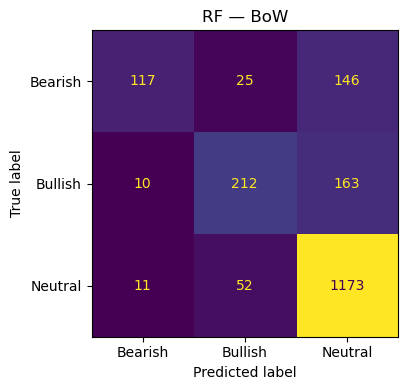


  Random Forest — TF-IDF
              precision    recall  f1-score   support

     Bearish       0.82      0.36      0.50       288
     Bullish       0.71      0.50      0.59       385
     Neutral       0.78      0.95      0.85      1236

    accuracy                           0.77      1909
   macro avg       0.77      0.61      0.65      1909
weighted avg       0.77      0.77      0.75      1909



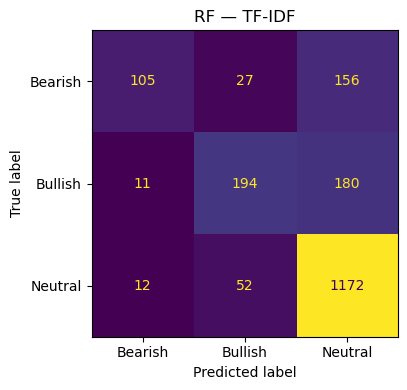

In [ ]:
rf_bow, _ = train_evaluate_rf(X_train_bow, X_val_bow, y_train, y_val, 
                               label="BoW")

# TF-IDF
rf_tfidf, _ = train_evaluate_rf(X_train_tfidf, X_val_tfidf, y_train, y_val,
                                 label="TF-IDF")

#### Test with word2vec, and glove


  Random Forest — Word2Vec Skip-gram
              precision    recall  f1-score   support

     Bearish       0.56      0.13      0.21       288
     Bullish       0.56      0.31      0.40       385
     Neutral       0.72      0.95      0.82      1236

    accuracy                           0.70      1909
   macro avg       0.61      0.46      0.48      1909
weighted avg       0.66      0.70      0.64      1909



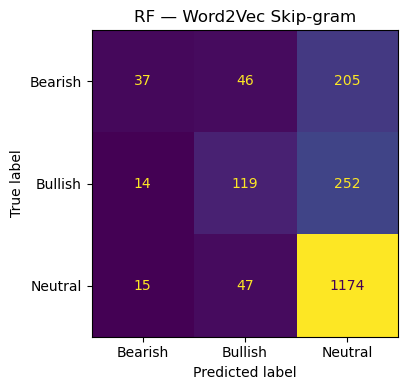


  Random Forest — Word2Vec CBOW
              precision    recall  f1-score   support

     Bearish       0.62      0.07      0.13       288
     Bullish       0.59      0.18      0.28       385
     Neutral       0.68      0.97      0.80      1236

    accuracy                           0.68      1909
   macro avg       0.63      0.41      0.40      1909
weighted avg       0.66      0.68      0.59      1909



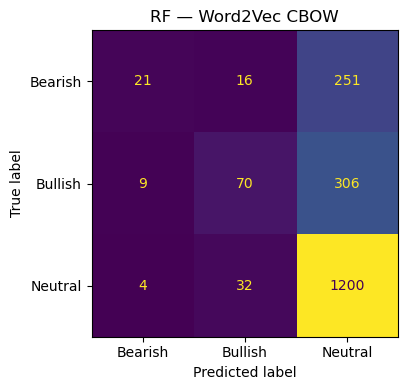


  Random Forest — GloVe-100
              precision    recall  f1-score   support

     Bearish       0.68      0.09      0.16       288
     Bullish       0.77      0.24      0.37       385
     Neutral       0.70      0.99      0.82      1236

    accuracy                           0.70      1909
   macro avg       0.71      0.44      0.45      1909
weighted avg       0.71      0.70      0.63      1909



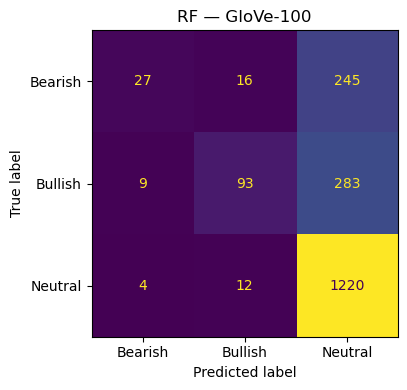

In [ ]:
# Word2Vec Skip-gram
rf_w2v, _ = train_evaluate_rf(X_train_w2v, X_val_w2v, y_train, y_val,
                               label="Word2Vec Skip-gram")

# Word2Vec CBOW
rf_w2v_cbow, _ = train_evaluate_rf(X_train_w2v_cbow, X_val_w2v_cbow, y_train, y_val,
                                    label="Word2Vec CBOW")

# GloVe
rf_glove, _ = train_evaluate_rf(X_train_glove_avg, X_val_glove_avg, y_train, y_val,
                                 label="GloVe-100")

#### Test with the CLS embeddings from FinBERT, RoBERTa and BERTweet


  Random Forest — FinBERT CLS
              precision    recall  f1-score   support

     Bearish       0.78      0.61      0.69       288
     Bullish       0.79      0.56      0.66       385
     Neutral       0.82      0.94      0.87      1236

    accuracy                           0.81      1909
   macro avg       0.80      0.70      0.74      1909
weighted avg       0.81      0.81      0.80      1909



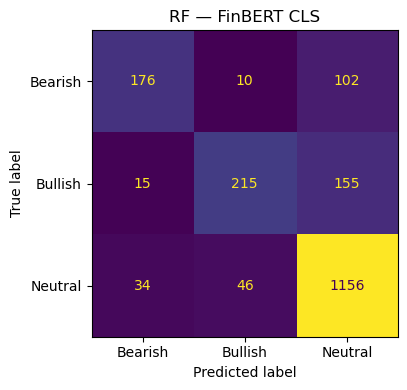


  Random Forest — RoBERTa CLS
              precision    recall  f1-score   support

     Bearish       0.88      0.20      0.33       288
     Bullish       0.74      0.45      0.56       385
     Neutral       0.76      0.98      0.85      1236

    accuracy                           0.76      1909
   macro avg       0.79      0.55      0.58      1909
weighted avg       0.77      0.76      0.72      1909



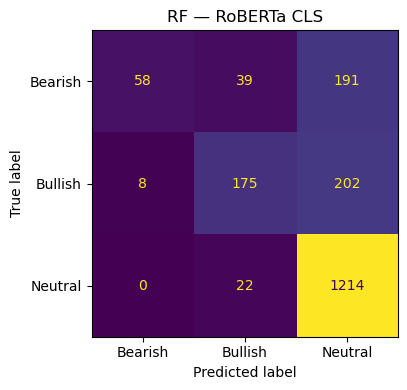


  Random Forest — BERTweet CLS
              precision    recall  f1-score   support

     Bearish       0.81      0.15      0.25       288
     Bullish       0.73      0.36      0.48       385
     Neutral       0.73      0.98      0.84      1236

    accuracy                           0.73      1909
   macro avg       0.76      0.50      0.52      1909
weighted avg       0.74      0.73      0.68      1909



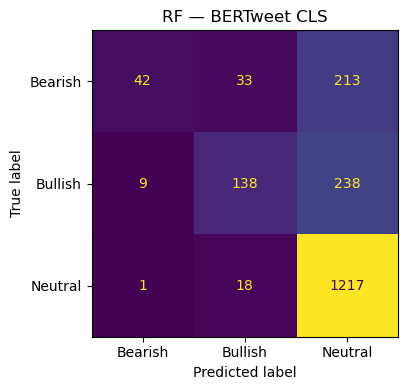

In [ ]:
rf_finbert, _ = train_evaluate_rf(X_train_finbert, X_val_finbert, y_train, y_val, label="FinBERT CLS")

rf_roberta, _ = train_evaluate_rf(X_train_roberta, X_val_roberta, y_train, y_val, label="RoBERTa CLS")

rf_bertweet, _ = train_evaluate_rf(X_train_bertweet, X_val_bertweet, y_train, y_val, label="BERTweet CLS")

In [ ]:
def check_data_shapes(X_train, X_val, label):
    print(f"\n--- {label} ---")
    print(f"\tX_train shape: {X_train.shape}")
    print(f"\tX_val shape: {X_val.shape}")
    
    # Para ver valores únicos (funciona para numpy e sparse)
    if hasattr(X_train, 'toarray'):
        # É matriz esparsa - converte uma pequena amostra
        sample = X_train[:10].toarray()
        print(f"\tUnique values in X_train sample: {np.unique(sample)[:10]}...")
        print(f"\tAny all-zero rows? {(X_train.toarray() == 0).all(axis=1).sum()}")
    else:
        # É numpy array normal
        print(f"\tUnique values in X_train: {np.unique(X_train[:10])}")
        print(f"\tAny all-zero rows? {(X_train == 0).all(axis=1).sum()}")
    
    # Verifica variância dos dados (importante!)
    if hasattr(X_train, 'toarray'):
        data_sample = X_train[:100].toarray()
    else:
        data_sample = X_train[:100]
    
    print(f"\tStd deviation of data: {data_sample.std():.6f}")
    print(f"\tMean of data: {data_sample.mean():.6f}")

# Verifica cada modelo
check_data_shapes(X_train_finbert, X_val_finbert, "FinBERT")
check_data_shapes(X_train_bow, X_val_bow, "BoW")
check_data_shapes(X_train_w2v, X_val_w2v, "Word2Vec")
check_data_shapes(X_train_glove_avg, X_val_glove_avg, "GloVe")


--- FinBERT ---
	X_train shape: (7634, 768)
	X_val shape: (1909, 768)
	Unique values in X_train: [-2.918073  -2.8785074 -2.8449316 ...  2.1013067  2.2925577  3.3046448]
	Any all-zero rows? 0
	Std deviation of data: 0.608167
	Mean of data: -0.016211

--- BoW ---
	X_train shape: (7634, 5000)
	X_val shape: (1909, 5000)
	Unique values in X_train sample: [0 1 2]...
	Any all-zero rows? 19
	Std deviation of data: 0.047348
	Mean of data: 0.002050

--- Word2Vec ---
	X_train shape: (7634, 100)
	X_val shape: (1909, 100)
	Unique values in X_train: [-6.22123241e-01 -5.57573855e-01 -5.33129394e-01 -4.79754418e-01
 -4.60361660e-01 -4.50389445e-01 -4.47562605e-01 -4.12937254e-01
 -3.97563308e-01 -3.91025752e-01 -3.86852562e-01 -3.85098636e-01
 -3.81462634e-01 -3.80206078e-01 -3.77997607e-01 -3.57475072e-01
 -3.54732007e-01 -3.52262437e-01 -3.50946754e-01 -3.42617720e-01
 -3.41608465e-01 -3.34062487e-01 -3.31352711e-01 -3.27552795e-01
 -3.25447649e-01 -3.10788095e-01 -3.09007198e-01 -3.07624698e-01
 -

In [ ]:
print(" GRID SEARCH - FINBERT CLS")

param_grid = {
    'n_estimators': [200, 300],   
    'max_depth': [20, None], 
    'min_samples_split': [2, 5],    
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_finbert, y_train)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best F1 macro (CV): {grid_search.best_score_:.4f}")

y_pred_best = grid_search.predict(X_val_finbert)

print("\n Results with best parameters:")
print(classification_report(y_val, y_pred_best, target_names=['Bearish', 'Bullish', 'Neutral']))

# Compare with original model
from sklearn.metrics import f1_score

# original model (default)
rf_default = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_default.fit(X_train_finbert, y_train)
y_pred_default = rf_default.predict(X_val_finbert)

f1_default = f1_score(y_val, y_pred_default, average='macro')
f1_best = f1_score(y_val, y_pred_best, average='macro')

print(f"Comparison:")
print(f" Original Model (default): F1 macro = {f1_default:.4f}")
print(f" Optimized Model: F1 macro = {f1_best:.4f}")
print(f" Improvement:{f1_best - f1_default:+.4f}")

 GRID SEARCH - FINBERT CLS
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
Best F1 macro (CV): 0.7537

 Results with best parameters:
              precision    recall  f1-score   support

     Bearish       0.73      0.66      0.69       288
     Bullish       0.78      0.60      0.68       385
     Neutral       0.84      0.92      0.87      1236

    accuracy                           0.81      1909
   macro avg       0.78      0.73      0.75      1909
weighted avg       0.81      0.81      0.81      1909

\Comparison:
 Original Model (default): F1 macro = 0.7381
 Optimized Model: F1 macro = 0.7496
 Improvement:+0.0115


In [ ]:
# SIMPLE COMPARISON TABLE - Random Forest Models

data = {
    'Model': ['FinBERT CLS', 'RoBERTa CLS', 'BoW', 'Word2Vec Skip-gram'],
    'Accuracy': ['81%', '76%', '79%', '70%'],
    'F1 Macro': [0.74, 0.58, 0.68, 0.48],
    'F1 Bearish': [0.69, 0.33, 0.55, 0.21],
    'F1 Bullish': [0.66, 0.56, 0.63, 0.40],
    'F1 Neutral': [0.87, 0.85, 0.86, 0.82]
}

df = pd.DataFrame(data)
df = df.sort_values('F1 Macro', ascending=False)

print("\n" + "-"*80)
print("Performance Comparison of Random Forest Models")
print("-"*80)
print(df.to_string(index=False))
print("-"*80)


--------------------------------------------------------------------------------
Performance Comparison of Random Forest Models
--------------------------------------------------------------------------------
             Model Accuracy  F1 Macro  F1 Bearish  F1 Bullish  F1 Neutral
       FinBERT CLS      81%      0.74        0.69        0.66        0.87
               BoW      79%      0.68        0.55        0.63        0.86
       RoBERTa CLS      76%      0.58        0.33        0.56        0.85
Word2Vec Skip-gram      70%      0.48        0.21        0.40        0.82
--------------------------------------------------------------------------------


#### Summary

**Best Model:** Random Forests with the FinBERT CLS embeddings (81% accuracy, macro F1: 0.74)

**Key Findings:**
- FinBERT CLS outperforms all other models, especially on minority classes (Bearish F1: 0.69, Bullish F1: 0.66)
- BoW provides a strong baseline (79% accuracy, macro F1: 0.68)
- RoBERTa CLS fails to capture Bearish sentiment effectively (F1: 0.33)
- Word2Vec Skip-gram performs poorly across all classes (macro F1: 0.48)

**Optimization:** Grid Search improved FinBERT's macro F1 by +1.15% (0.738 → 0.750)

#### Final RF - FinBERT Model test with Optimized Parameters

Training Final FinBERT Model with Optimized Parameters
--------------------------------------------------

Final model performance (Validation Set)
              precision    recall  f1-score   support

     Bearish       0.73      0.66      0.69       288
     Bullish       0.78      0.60      0.68       385
     Neutral       0.84      0.92      0.87      1236

    accuracy                           0.81      1909
   macro avg       0.78      0.73      0.75      1909
weighted avg       0.81      0.81      0.81      1909



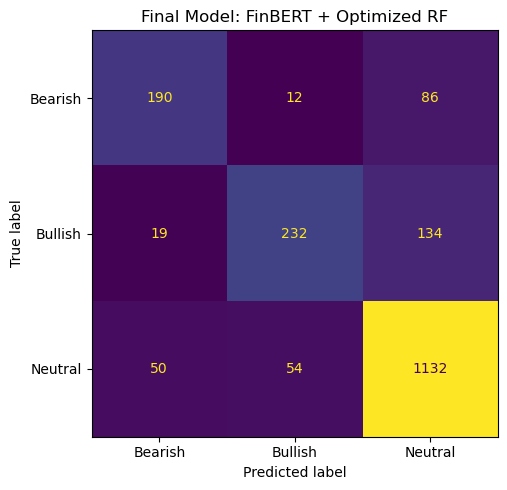

['final_rf_finbert_optimized.pkl']

In [ ]:
# Train final model with optimized parameters
print("Training Final FinBERT Model with Optimized Parameters")
print("-" * 50)

# Define the optimized model
final_rf = RandomForestClassifier(
    n_estimators=300,        # number of trees
    max_depth=20,            # maximum depth of each tree
    min_samples_split=5,     # minimum samples required to split a node
    class_weight='balanced', # handle class imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

final_rf.fit(X_train_finbert, y_train)

# Evaluate on validation set
y_pred_final = final_rf.predict(X_val_finbert)

print("\n" + "="*50)
print("Final model performance (Validation Set)")
print("="*50)
print(classification_report(y_val, y_pred_final, target_names=['Bearish', 'Bullish', 'Neutral']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=['Bearish', 'Bullish', 'Neutral'])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Final Model: FinBERT + Optimized RF")
plt.tight_layout()
plt.show()

# Save the model for later use
joblib.dump(final_rf, 'final_rf_finbert_optimized.pkl')

### 8.2 XGBoost

In [ ]:
def evaluate_model_predictions(y_pred_train, y_pred_val, y_train = y_train, y_val = y_val, show_confusion_matrix = True, show_classification_report = True):
    """
    Evaluate the performance of a classification model on training and validation sets.

    Computes and prints accuracy, F1-score (macro), precision, and recall for both sets.
    Optionally displays the confusion matrix and detailed classification report for the validation set.

    Parameters:
    y_pred_train (array-like): Predicted labels for the training set.
    y_pred_val (array-like): Predicted labels for the validation set.
    y_train (array-like, optional): True labels for the training set.
    y_val (array-like, optional): True labels for the validation set.
    show_confusion_matrix (bool): If True, prints the confusion matrix for the validation set.
    show_classification_report (bool): If True, prints the classification report for the validation set.

    Returns:
    tuple: A tuple containing:
        - train_accuracy (float)
        - train_f1 (float)
        - val_accuracy (float)
        - val_f1 (float)
    """
    
    # to get the accurancy and the macro f1 score of the model on the training set
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train, average='macro')
    
    # to get the accurancy and the macro f1 score of the model on the validation set
    val_accuracy = accuracy_score(y_val, y_pred_val)
    val_f1 = f1_score(y_val, y_pred_val, average='macro')

    # to get the precision and the recall of the model on the validation set
    val_precision = precision_score(y_val, y_pred_val, average='macro')
    val_recall = recall_score(y_val, y_pred_val, average='macro')

    print(f"Accuracy of train: {train_accuracy:.4f}")
    print(f"F1 Macro (Train): {train_f1:.4f}")
    print(f"Accuracy of val: {val_accuracy:.4f}")
    print(f"\033[1mF1 Macro (Val)\033[0m: {val_f1:.4f}")
    print(f"Precision (Val): {val_precision:.4f}")
    print(f"Recall (Val): {val_recall:.4f}")
    
    # to get the confusion matrix and the classification report of the model on the validation set
    if show_confusion_matrix==True:
        print('\nConfusion Matrix for Validation Data:')    
        print(confusion_matrix(y_val, y_pred_val))

    if show_classification_report==True:
        print('\nClassification Report for Validation Data:')
        print(classification_report(y_val, y_pred_val))

    return val_accuracy, val_f1, val_precision, val_recall

#### TD-IDF

In [ ]:
clf_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=13)
clf_xgb.fit(X_train_tfidf, y_train)
y_pred_train = clf_xgb.predict(X_train_tfidf)
y_pred_val = clf_xgb.predict(X_val_tfidf)

xgb_idf_accuracy, xgb_idf_f1_macro, xgb_idf_precision, xgb_idf_recall = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val)

c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of train: 0.7828
F1 Macro (Train): 0.6520
Accuracy of val: 0.7402
F1 Macro (Val): 0.5772
Precision (Val): 0.7956
Recall (Val): 0.5305

Confusion Matrix for Validation Data:
[[  83    7  198]
 [   5  127  253]
 [   9   24 1203]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.86      0.29      0.43       288
           1       0.80      0.33      0.47       385
           2       0.73      0.97      0.83      1236

    accuracy                           0.74      1909
   macro avg       0.80      0.53      0.58      1909
weighted avg       0.76      0.74      0.70      1909



In [ ]:
clf_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=13)
clf_xgb.fit(X_train_tfidf_no_sw, y_train_no_sw)
y_pred_train = clf_xgb.predict(X_train_tfidf_no_sw)
y_pred_val = clf_xgb.predict(X_val_tfidf_no_sw)

xgb_idf_accuracy_no_sw, xgb_idf_f1_macro_no_sw, xgb_idf_precision_no_sw, xgb_idf_recall_no_sw = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val)

c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of train: 0.7632
F1 Macro (Train): 0.6079
Accuracy of val: 0.7229
F1 Macro (Val): 0.5347
Precision (Val): 0.7659
Recall (Val): 0.4978

Confusion Matrix for Validation Data:
[[  65   11  212]
 [   4  114  267]
 [  10   25 1201]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.82      0.23      0.35       288
           1       0.76      0.30      0.43       385
           2       0.71      0.97      0.82      1236

    accuracy                           0.72      1909
   macro avg       0.77      0.50      0.53      1909
weighted avg       0.74      0.72      0.67      1909



##### **Key Observations**

- **Stop word removal improves all metrics marginally**: Val F1 Macro increases from 0.535 to 0.577 and Val Accuracy from 0.72 to 0.74, making it the preferred preprocessing choice.
- **Class imbalance is the dominant issue in both runs.** Classes 0 and 1 show very low recall (0.29/0.33 with SW, 0.23/0.30 without), while class 2 consistently reaches 0.97 recall, indicating the model defaults to the majority class.
- **Precision for classes 0 and 1 remains relatively high** (0.80) in both runs, meaning predictions for minority classes are often correct, the model simply avoids predicting them.
- **Mild overfitting is present in both runs**, more pronounced without stop words (train-val F1 gap of 0.073 vs. 0.055).
- **Overall accuracy is high**, but it is not fully representative of model performance due to strong class imbalance, as it is largely driven by the majority class (class 2).

#### Glove

In [ ]:
clf_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=13)
clf_xgb.fit(X_train_glove_avg, y_train)
y_pred_train = clf_xgb.predict(X_train_glove_avg)
y_pred_val = clf_xgb.predict(X_val_glove_avg)

xgb_glove_accuracy, xgb_glove_f1_macro, xgb_glove_precision, xgb_glove_recall = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val)

c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of train: 0.8398
F1 Macro (Train): 0.7619
Accuracy of val: 0.7360
F1 Macro (Val): 0.5629
Precision (Val): 0.6810
Recall (Val): 0.5320

Confusion Matrix for Validation Data:
[[  69   45  174]
 [  21  154  210]
 [  20   34 1182]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.63      0.24      0.35       288
           1       0.66      0.40      0.50       385
           2       0.75      0.96      0.84      1236

    accuracy                           0.74      1909
   macro avg       0.68      0.53      0.56      1909
weighted avg       0.72      0.74      0.70      1909



In [ ]:
clf_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=13)
clf_xgb.fit(X_train_glove_avg_no_sw, y_train_no_sw)
y_pred_train = clf_xgb.predict(X_train_glove_avg_no_sw)
y_pred_val = clf_xgb.predict(X_val_glove_avg_no_sw)

xgb_glove_accuracy_no_sw, xgb_glove_f1_macro_no_sw, xgb_glove_precision_no_sw, xgb_glove_recall_no_sw = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val)

c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of train: 0.8253
F1 Macro (Train): 0.7363
Accuracy of val: 0.7255
F1 Macro (Val): 0.5387
Precision (Val): 0.6737
Recall (Val): 0.5093

Confusion Matrix for Validation Data:
[[  63   34  191]
 [  25  134  226]
 [  14   34 1188]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.62      0.22      0.32       288
           1       0.66      0.35      0.46       385
           2       0.74      0.96      0.84      1236

    accuracy                           0.73      1909
   macro avg       0.67      0.51      0.54      1909
weighted avg       0.71      0.73      0.68      1909



Removing stop words slightly degrades performance (lower F1-macro and recall), suggesting they were not harmful and may have provided useful signal for the model rather than noise in this setup.

F1 Macro on validation set was equal to **0.5387** and in train was **0.7363** without the stop words.

F1 Macro on validation set was equal to **0.5629** and in train was **0.7619** with stop words.

#### RoBERTa

In [ ]:
clf_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=13)
clf_xgb.fit(X_train_roberta, y_train_raw)
y_pred_train = clf_xgb.predict(X_train_roberta)
y_pred_val = clf_xgb.predict(X_val_roberta)

xgb_roberta_accuracy, xgb_roberta_f1_macro, xgb_roberta_precision, xgb_roberta_recall = evaluate_model_predictions(y_pred_train, y_pred_val, y_train=y_train_raw, y_val=y_val_raw)

c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of train: 0.9311
F1 Macro (Train): 0.9094
Accuracy of val: 0.8041
F1 Macro (Val): 0.7012
Precision (Val): 0.7590
Recall (Val): 0.6698

Confusion Matrix for Validation Data:
[[ 129   47  112]
 [  27  237  121]
 [  23   44 1169]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.72      0.45      0.55       288
           1       0.72      0.62      0.66       385
           2       0.83      0.95      0.89      1236

    accuracy                           0.80      1909
   macro avg       0.76      0.67      0.70      1909
weighted avg       0.79      0.80      0.79      1909



#### Comparison of models

In [ ]:
# Compare the results of the different models in a table format
print("\nComparison of XGBoost Models:")
print(f"XGBoost with TF-IDF (with stop words) - Accuracy: {xgb_idf_accuracy:.4f}, F1 Macro: {xgb_idf_f1_macro:.4f}, Precision: {xgb_idf_precision:.4f}, Recall: {xgb_idf_recall:.4f}")
print(f"XGBoost with TF-IDF (no stop words) - Accuracy: {xgb_idf_accuracy_no_sw:.4f}, F1 Macro: {xgb_idf_f1_macro_no_sw:.4f}, Precision: {xgb_idf_precision_no_sw:.4f}, Recall: {xgb_idf_recall_no_sw:.4f}")
print(f"XGBoost with GloVe (with stop words) - Accuracy: {xgb_glove_accuracy:.4f}, F1 Macro: {xgb_glove_f1_macro:.4f}, Precision: {xgb_glove_precision:.4f}, Recall: {xgb_glove_recall:.4f}")
print(f"XGBoost with GloVe (no stop words) - Accuracy: {xgb_glove_accuracy_no_sw:.4f}, F1 Macro: {xgb_glove_f1_macro_no_sw:.4f}, Precision: {xgb_glove_precision_no_sw:.4f}, Recall: {xgb_glove_recall_no_sw:.4f}")
print(f"XGBoost with RoBERTa - Accuracy: {xgb_roberta_accuracy:.4f}, F1 Macro: {xgb_roberta_f1_macro:.4f}, Precision: {xgb_roberta_precision:.4f}, Recall: {xgb_roberta_recall:.4f}")


Comparison of XGBoost Models:
XGBoost with TF-IDF (with stop words) - Accuracy: 0.7402, F1 Macro: 0.5772, Precision: 0.7956, Recall: 0.5305
XGBoost with TF-IDF (no stop words) - Accuracy: 0.7229, F1 Macro: 0.5347, Precision: 0.7659, Recall: 0.4978
XGBoost with GloVe (with stop words) - Accuracy: 0.7360, F1 Macro: 0.5629, Precision: 0.6810, Recall: 0.5320
XGBoost with GloVe (no stop words) - Accuracy: 0.7255, F1 Macro: 0.5387, Precision: 0.6737, Recall: 0.5093
XGBoost with RoBERTa - Accuracy: 0.8041, F1 Macro: 0.7012, Precision: 0.7590, Recall: 0.6698


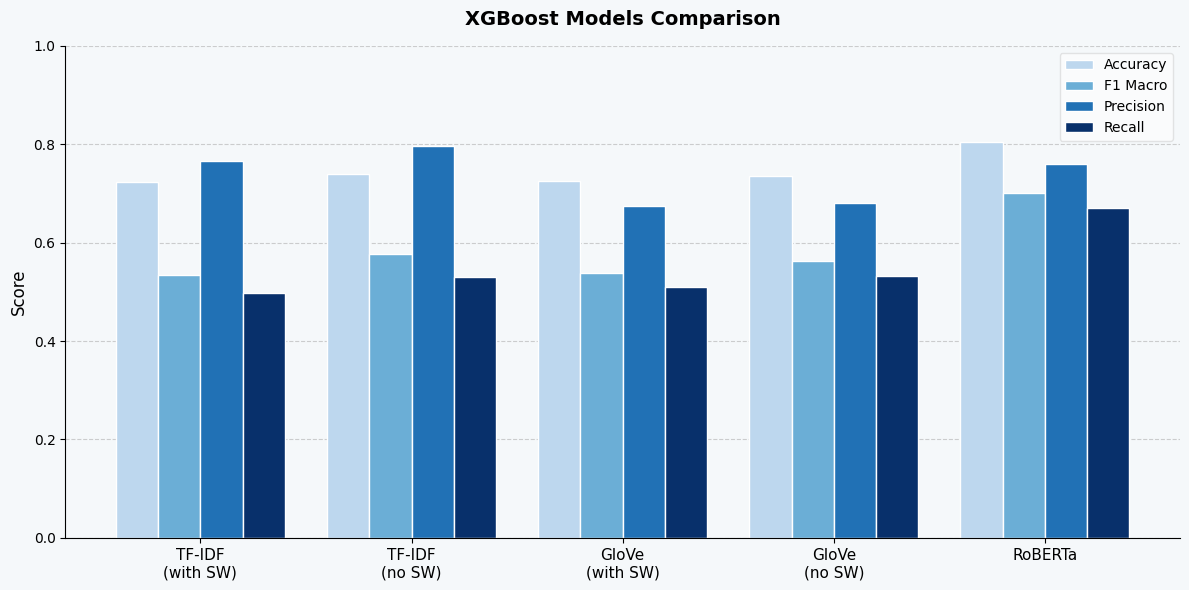

In [ ]:
models = [
    "TF-IDF\n(with SW)",
    "TF-IDF\n(no SW)",
    "GloVe\n(with SW)",
    "GloVe\n(no SW)",
    "RoBERTa"
]

accuracy  = [xgb_idf_accuracy_no_sw,  xgb_idf_accuracy,  xgb_glove_accuracy_no_sw,  xgb_glove_accuracy,  xgb_roberta_accuracy]
f1_macro  = [xgb_idf_f1_macro_no_sw,  xgb_idf_f1_macro,  xgb_glove_f1_macro_no_sw,  xgb_glove_f1_macro,  xgb_roberta_f1_macro]
precision = [xgb_idf_precision_no_sw, xgb_idf_precision, xgb_glove_precision_no_sw, xgb_glove_precision, xgb_roberta_precision]
recall    = [xgb_idf_recall_no_sw,    xgb_idf_recall,    xgb_glove_recall_no_sw,    xgb_glove_recall,    xgb_roberta_recall]

x = np.arange(len(models))
width = 0.2

colors = ['#BDD7EE', '#6BAED6', '#2171B5', '#08306B']

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F5F8FA')
ax.set_facecolor('#F5F8FA')

ax.bar(x - 1.5*width, accuracy,  width, label='Accuracy',  color=colors[0], edgecolor='white')
ax.bar(x - 0.5*width, f1_macro,  width, label='F1 Macro',  color=colors[1], edgecolor='white')
ax.bar(x + 0.5*width, precision, width, label='Precision', color=colors[2], edgecolor='white')
ax.bar(x + 1.5*width, recall,    width, label='Recall',    color=colors[3], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("XGBoost Models Comparison", fontsize=14, fontweight='bold', pad=15)
ax.legend(framealpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Among all feature representations, RoBERTa embeddings achieved the best score, obtaining the highest Macro F1-score and Recall. Given the class imbalance, Macro F1 is considered more informative than Accuracy. Therefore, Grid Search will be performed on the Random Forest trained with RoBERTa embeddings to further optimize its performance.

In [ ]:
## GridSearchCV for XGBoost with RoBERTa

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

clf_grid = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=13
)

grid_search = GridSearchCV(
    estimator=clf_grid,
    param_grid=param_grid,
    scoring='f1_macro',   # optimiza para F1 Macro
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_roberta, y_train_raw)

print("Best params:", grid_search.best_params_)
print("Best F1 Macro (CV):", grid_search.best_score_)

# Avaliar no validation
best_model = grid_search.best_estimator_
y_pred_train = best_model.predict(X_train_roberta)
y_pred_val = best_model.predict(X_val_roberta)

xgb_roberta_accuracy_grid, xgb_roberta_f1_macro_grid, xgb_roberta_precision_grid, xgb_roberta_recall_grid = evaluate_model_predictions(
    y_pred_train, y_pred_val, y_train=y_train_raw, y_val=y_val_raw
)



Fitting 3 folds for each of 108 candidates, totalling 324 fits


c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:18:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best F1 Macro (CV): 0.7474496842753355
Accuracy of train: 0.9993
F1 Macro (Train): 0.9992
Accuracy of val: 0.8250
F1 Macro (Val): 0.7520
Precision (Val): 0.7860
Recall (Val): 0.7271

Confusion Matrix for Validation Data:
[[ 172   28   88]
 [  27  251  107]
 [  32   52 1152]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.74      0.60      0.66       288
           1       0.76      0.65      0.70       385
           2       0.86      0.93      0.89      1236

    accuracy                           0.83      1909
   macro avg       0.79      0.73      0.75      1909
weighted avg       0.82      0.83      0.82      1909



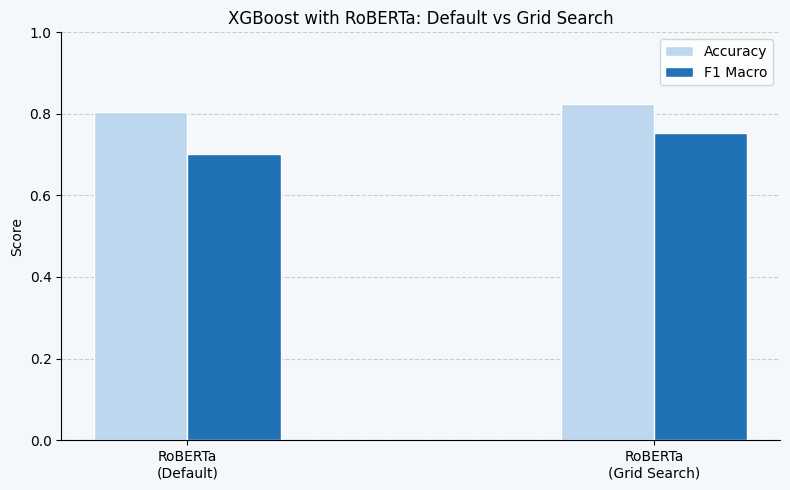

In [ ]:
models = ["RoBERTa\n(Default)", "RoBERTa\n(Grid Search)"]
accuracy  = [xgb_roberta_accuracy, xgb_roberta_accuracy_grid]
f1_macro  = [xgb_roberta_f1_macro, xgb_roberta_f1_macro_grid]
precision = [xgb_roberta_precision, xgb_roberta_precision_grid]
recall    = [xgb_roberta_recall, xgb_roberta_recall_grid]
x = np.arange(len(models))
width = 0.2
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#F5F8FA')
ax.set_facecolor('#F5F8FA')
ax.bar(x - width/2, accuracy,  width, label='Accuracy',  color='#BDD7EE', edgecolor='white')
ax.bar(x + width/2, f1_macro,  width, label='F1 Macro',  color='#2171B5', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("XGBoost with RoBERTa: Default vs Grid Search")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Grid Search improved the original model.

The final model was:

#### Cross-Validation Performance

- **Best F1 Macro (3-fold CV):** `0.7474`

#### Training Performance

| Metric | Score |
|---------|--------|
| Accuracy | 0.9993 |
| F1 Macro | 0.9992 |

#### Validation Performance

| Metric | Score |
|---------|--------|
| Accuracy | 0.8250 |
| F1 Macro | **0.7520** |
| Precision (Macro) | 0.7860 |
| Recall (Macro) | 0.7271 |


Given the class imbalance observed in the dataset, the **macro F1-score (0.7520)** provides a more informative measure of performance than accuracy alone, as it evaluates the model's effectiveness across all classes equally.

We can see that we have overfitting, which can being caused because of class imbalance.

### 8.3 FinBERT

FinBERT is a pre-trained NLP model to analyze sentiment of financial text. It is built by further training the BERT language model in the finance domain, using a large financial corpus and thereby fine-tuning it for financial sentiment classification. [https://huggingface.co/ProsusAI/finbert]<br>

This pre-trained model was trained in english text, knowing that we have non-english tweets we will test with three differnt scenarios:

- With the raw data;
- With the translated data;
- Only with the english data

In [ ]:
MODEL = "ProsusAI/finbert"

# Load Hugging Face pipeline
hf_classifier = pipeline(
    "text-classification",
    model=MODEL,
    tokenizer=MODEL,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True
)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

#### With the Raw Data

In [ ]:

# Make predictions
preds_train = hf_classifier(list(X_train_raw))
preds_val = hf_classifier(list(X_val_raw))

# Map model's labels to integers
label_to_int = {
    "positive": 1,  # Bullish
    "negative": 0,  # Bearish
    "neutral":  2   # Neutral
}

y_pred_train = [label_to_int[pred["label"]] for pred in preds_train]
y_pred_val   = [label_to_int[pred["label"]] for pred in preds_val]

# Evaluation
finberta_accuracy, finberta_f1_macro, finberta_precision, finberta_recall = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val, y_train = y_train_raw, y_val = y_val_raw)

Accuracy of train: 0.7117
F1 Macro (Train): 0.6619
Accuracy of val: 0.7140
F1 Macro (Val): 0.6627
Precision (Val): 0.6441
Recall (Val): 0.7059

Confusion Matrix for Validation Data:
[[230  16  42]
 [ 50 225 110]
 [172 156 908]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.51      0.80      0.62       288
           1       0.57      0.58      0.58       385
           2       0.86      0.73      0.79      1236

    accuracy                           0.71      1909
   macro avg       0.64      0.71      0.66      1909
weighted avg       0.75      0.71      0.72      1909



#### With the Translated Data

To tranlate the non-English tweets to English Helsinki-NLP/opus-mt-{src_lang}-en famaly of models was used. Which for each  src_lang will tranlate to english. [https://huggingface.co/Helsinki-NLP]

In [ ]:
SUPPORTED_LANGS = ['en', 'fr', 'es', 'de', 'it', 'nl', 'ru', 'zh', 'ja', 'ar', 'fi', 'hu', 'vi', 'sv', 'cs', 'da', 'is']
loaded_models = {}

def load_translation_model(src_lang):
    model_name = f'Helsinki-NLP/opus-mt-{src_lang}-en'
    if model_name not in loaded_models:
        tokenizer = MarianTokenizer.from_pretrained(model_name)
        model = MarianMTModel.from_pretrained(model_name)
        loaded_models[model_name] = (tokenizer, model)
    return loaded_models[model_name]

def translate_text(text, src_lang):
    if src_lang == 'en' or src_lang not in SUPPORTED_LANGS:
        return text  
    try:
        tokenizer, model = load_translation_model(src_lang)
        batch = tokenizer([text], return_tensors="pt", padding=True, truncation=True)
        generated = model.generate(**batch)
        translated = tokenizer.decode(generated[0], skip_special_tokens=True)
        return translated
    except Exception as e:
        print(f"Error translating ({src_lang}): {e}")
        return text

train['translated_text'] = [
    translate_text(text, lang)
    for text, lang in tqdm(zip(train['text'], train['language']), total=len(train))]


# to see it its translating well:
train[train['language'] == 'fr']

  0%|          | 0/9543 [00:00<?, ?it/s]/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

 15%|█▍        | 1415/9543 [00:03<00:22, 367.70it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

 92%|█████████▏| 8790/9543 [01:29<00:20, 36.48it/s] 

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

100%|██████████| 9543/9543 [01:34<00:00, 101.22it/s]


,text,label,sentiment,clean_text,clean_text_no_sw,light_clean,language,translated_text
1449,Eudonet annonce un chiffre d’affaires récurren...,2,Neutral,eudonet annonce un chiffre d affaire récurrent...,eudonet annonce un chiffre affaire récurrent e...,eudonet annonce un chiffre d’affaires récurren...,fr,Eudonet announces a 32% increase in recurring ...
1837,Rio Tinto’s Giant Mongolia Project Dealt Anoth...,2,Neutral,rio tinto s giant mongolia project dealt anoth...,rio tinto giant mongolia project dealt another...,rio tinto’s giant mongolia project dealt anoth...,fr,Rio Tinto的s Giant Mongolia Project Dealt Anoth...
1962,Tinyclues accélère sa croissance en 2019,2,Neutral,tinyclues accélère sa croissance en,tinyclues accélère sa croissance en,tinyclues accélère sa croissance en 2019,fr,Tinyclues accelerates its growth in 2019
4318,Cloudia lance la dernière génération de soluti...,2,Neutral,cloudia lance la dernière génération de soluti...,cloudia lance la dernière génération de soluti...,cloudia lance la dernière génération de soluti...,fr,Cloudia launches the latest generation of Proc...
4785,Korian s’associe à Omedys pour développer le p...,2,Neutral,korian s associe à omedys pour développer le p...,korian associe à omedys pour développer le pre...,korian s’associe à omedys pour développer le p...,fr,Korian is partnering with Omedys to develop th...
5352,Total : Résultats du quatrième trimestre et de...,2,Neutral,total résultats du quatrième trimestre et de l...,total résultats du quatrième trimestre et de l...,total : résultats du quatrième trimestre et de...,fr,Total: Results for the fourth quarter and the ...
5499,Will China Declare Force Majeure If Virus Situ...,2,Neutral,will china declare force majeure if virus situ...,china declare force majeure virus situation wo...,will china declare force majeure if virus situ...,fr,Will China Declare Force Major If Virus Situat...
8448,DFND,2,Neutral,dfnd,dfnd,dfnd,fr,DFND
8590,HOML,2,Neutral,homl,homl,homl,fr,HOML
8707,Is Les Hôtels de Paris (EPA:HDP) Using Too Muc...,2,Neutral,is le hôtels de paris epa hdp using too much d...,le hôtels de paris epa hdp using much debt?,is les hôtels de paris (epa:hdp) using too muc...,fr,Is Hotels in Paris (EPA:HDP) Using Too Much Debt?


In [ ]:
X_val_translated = train.loc[X_val_raw.index, 'translated_text']
X_train_translated = train.loc[X_train_raw.index, 'translated_text']
# Make predictions
preds_train = hf_classifier(list(X_train_translated))
preds_val = hf_classifier(list(X_val_translated))

# Map model's labels to integers
label_to_int = {
    "positive": 1,  # Bullish
    "negative": 0,  # Bearish
    "neutral":  2   # Neutral
}

y_pred_train = [label_to_int[pred["label"]] for pred in preds_train]
y_pred_val   = [label_to_int[pred["label"]] for pred in preds_val]

# Evaluation
finberta_accuracy_trans, finberta_f1_macro_trans, finberta_precision_trans, finberta_recall_trans = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val, y_train = y_train_raw, y_val = y_val_raw)

Accuracy of train: 0.7109
F1 Macro (Train): 0.6613
Accuracy of val: 0.7114
F1 Macro (Val): 0.6606
Precision (Val): 0.6415
Recall (Val): 0.7045

Confusion Matrix for Validation Data:
[[230  16  42]
 [ 50 225 110]
 [172 161 903]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.51      0.80      0.62       288
           1       0.56      0.58      0.57       385
           2       0.86      0.73      0.79      1236

    accuracy                           0.71      1909
   macro avg       0.64      0.70      0.66      1909
weighted avg       0.74      0.71      0.72      1909



#### With Only the English Data

In [ ]:
eng_mask_val = train.loc[X_val_raw.index, 'language'] == 'en'
y_val_eng = y_val_raw.loc[eng_mask_val[eng_mask_val].index]
X_val_eng = X_val_raw.loc[eng_mask_val[eng_mask_val].index]

eng_mask_train = train.loc[X_train_raw.index, 'language'] == 'en'
y_train_eng = y_train_raw.loc[eng_mask_train[eng_mask_train].index]
X_train_eng = X_train_raw.loc[eng_mask_train[eng_mask_train].index]

# Make predictions
preds_train = hf_classifier(list(X_train_eng))
preds_val = hf_classifier(list(X_val_eng))

# Map model's labels to integers
label_to_int = {
    "positive": 1,  # Bullish
    "negative": 0,  # Bearish
    "neutral":  2   # Neutral
}

y_pred_train = [label_to_int[pred["label"]] for pred in preds_train]
y_pred_val   = [label_to_int[pred["label"]] for pred in preds_val]

# Evaluation
finberta_accuracy_trans, finberta_f1_macro_trans, finberta_precision_trans, finberta_recall_trans = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val, y_train = y_train_eng, y_val = y_val_eng)


Accuracy of train: 0.7098
F1 Macro (Train): 0.6615
Accuracy of val: 0.7125
F1 Macro (Val): 0.6625
Precision (Val): 0.6440
Recall (Val): 0.7055

Confusion Matrix for Validation Data:
[[230  16  42]
 [ 50 225 109]
 [171 156 893]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.51      0.80      0.62       288
           1       0.57      0.59      0.58       384
           2       0.86      0.73      0.79      1220

    accuracy                           0.71      1892
   macro avg       0.64      0.71      0.66      1892
weighted avg       0.74      0.71      0.72      1892



#### Conclusion

| Type of data | Tran F1 score | Validation F1score | 
|---|---|---|
|  raw data | 0.6619 |  0.6627 | 
| translated data | 0.6613 | 0.6606| 
| only english data | 0.6615 | 0.6625 | 

As we can see there is not much difference between the three different data, this can be due the fake positives of the model when predicting the language of each tweet. This can happen, for example, if an English tweet is talking about a foreigner company the model may pick on that and assume that the tweet is the language of the foreigner company. Also, when translating data, it can add noise if we translate to a wrongly classified foreign language or lose the contextual meaning during translation.
The best data was the original one, the raw data, where we got the results of the F1 score 0.6619 and 0.6627, for train and validation respectfully.

### 8.4 BERTtweet

BERTweet shares the same architecture as BERT-base, but it’s pretrained like RoBERTa on English Tweets. It performs really well on Tweet-related tasks like part-of-speech tagging, named entity recognition, and text classification. [https://huggingface.co/docs/transformers/model_doc/bertweet]

Since our goal is to do sentimental analyse of the stock tweets we find this model intresting t know how it will performe with our data.<br>
Like FINBERT, this model was trained as well in english tweets so we will preside as well with three differnt scenarios:

- With the raw data;
- With the translated data;
- Only with the english data

In [ ]:
# Choose a pretrained BERTweet sentiment classifier
MODEL = "finiteautomata/bertweet-base-sentiment-analysis"

# Load Hugging Face pipeline for text classification
hf_classifier = pipeline(
    "text-classification",
    model=MODEL,
    tokenizer=MODEL,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True
)


#### With raw data

In [ ]:

# Make predictions on raw validation tweets
preds_train = hf_classifier(list(X_train_raw))
preds_val = hf_classifier(list(X_val_raw))

# Map the model’s label strings to your integer classes
label_to_int = {
    "NEG": 0,  # negative → Bearish
    "NEU": 2,  # neutral  → Neutral
    "POS": 1   # positive → Bullish
}

y_pred_train = [label_to_int[pred['label']] for pred in preds_train]
y_pred_val = [label_to_int[pred['label']] for pred in preds_val]


# Evaluation
bertweet_accuracy, bertweet_f1_macro, bertweet_precision, bertweet_recall = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val, y_train = y_train_raw, y_val = y_val_raw)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Accuracy of train: 0.6719
F1 Macro (Train): 0.5893
Accuracy of val: 0.6679
F1 Macro (Val): 0.5911
Precision (Val): 0.5937
Recall (Val): 0.5928

Confusion Matrix for Validation Data:
[[179   2 107]
 [ 11 151 223]
 [131 160 945]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.56      0.62      0.59       288
           1       0.48      0.39      0.43       385
           2       0.74      0.76      0.75      1236

    accuracy                           0.67      1909
   macro avg       0.59      0.59      0.59      1909
weighted avg       0.66      0.67      0.66      1909



#### With translated data

In [ ]:
X_val_translated = train.loc[X_val_raw.index, 'translated_text']
X_train_translated = train.loc[X_train_raw.index, 'translated_text']
# Load Hugging Face pipeline for text classification
hf_classifier = pipeline(
    "text-classification",
    model=MODEL,
    tokenizer=MODEL,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True
)

# Make predictions on raw validation tweets
preds_train = hf_classifier(list(X_train_translated))
preds_val = hf_classifier(list(X_val_translated))

# Map the model’s label strings to your integer classes
label_to_int = {
    "NEG": 0,  # negative → Bearish
    "NEU": 2,  # neutral  → Neutral
    "POS": 1   # positive → Bullish
}

y_pred_train = [label_to_int[pred['label']] for pred in preds_train]
y_pred_val = [label_to_int[pred['label']] for pred in preds_val]


# Evaluation
bertweet_accuracy, bertweet_f1_macro, bertweet_precision, bertweet_recall = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val, y_train = y_train_raw, y_val = y_val_raw)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Accuracy of train: 0.6702
F1 Macro (Train): 0.5881
Accuracy of val: 0.6653
F1 Macro (Val): 0.5892
Precision (Val): 0.5909
Recall (Val): 0.5914

Confusion Matrix for Validation Data:
[[179   2 107]
 [ 11 151 223]
 [131 165 940]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.56      0.62      0.59       288
           1       0.47      0.39      0.43       385
           2       0.74      0.76      0.75      1236

    accuracy                           0.67      1909
   macro avg       0.59      0.59      0.59      1909
weighted avg       0.66      0.67      0.66      1909



#### With only english data

In [ ]:
eng_mask_val = train.loc[X_val_raw.index, 'language'] == 'en'
y_val_eng = y_val_raw.loc[eng_mask_val[eng_mask_val].index]
X_val_eng = X_val_raw.loc[eng_mask_val[eng_mask_val].index]

eng_mask_train = train.loc[X_train_raw.index, 'language'] == 'en'
y_train_eng = y_train_raw.loc[eng_mask_train[eng_mask_train].index]
X_train_eng = X_train_raw.loc[eng_mask_train[eng_mask_train].index]

# Make predictions
preds_train = hf_classifier(list(X_train_eng))
preds_val = hf_classifier(list(X_val_eng))

# Map model's labels to integers
label_to_int = {
    "NEG": 0,  # negative → Bearish
    "NEU": 2,  # neutral  → Neutral
    "POS": 1   # positive → Bullish
}


y_pred_train = [label_to_int[pred["label"]] for pred in preds_train]
y_pred_val   = [label_to_int[pred["label"]] for pred in preds_val]

# Evaluation
bertweet_accuracy, bertweet_f1_macro, bertweet_precision, bertweet_recall = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val, y_train = y_train_eng, y_val = y_val_eng)

Accuracy of train: 0.6695
F1 Macro (Train): 0.5886
Accuracy of val: 0.6649
F1 Macro (Val): 0.5895
Precision (Val): 0.5921
Recall (Val): 0.5912

Confusion Matrix for Validation Data:
[[179   2 107]
 [ 11 150 223]
 [131 160 929]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.56      0.62      0.59       288
           1       0.48      0.39      0.43       384
           2       0.74      0.76      0.75      1220

    accuracy                           0.66      1892
   macro avg       0.59      0.59      0.59      1892
weighted avg       0.66      0.66      0.66      1892



#### Conclusion

| Type of data | Tran F1 score | Validation F1score | 
|---|---|---|
|  raw data | 0.5893 |  0.5911 | 
| translated data | 0.5881 | 0.5892| 
| only english data | 0.5886 | 0.5895 | 

Similiar to FINBERT, BERTtweet produces consistent F1 scores throughout the three scenarios. The raw data got better results, probably due the same reasons as in FINBERT, the non-English tweets don't add noise, but trying to translate or remove them may add noise and remove important keys to classify the tweets.

### Fine Tuning

In [ ]:
# 1. Load BASE model (no sentiment head)
tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base")
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base", num_labels=3)

# 2. Create a dataset class
class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True)
        self.labels = list(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1 = f1_score(labels, predictions, average='macro')
    accuracy = accuracy_score(labels, predictions)
    return {"f1_macro": f1, "accuracy": accuracy}

train_dataset = TweetDataset(X_train_raw, y_train_raw)
val_dataset   = TweetDataset(X_val_raw, y_val_raw)

# 3. Define training arguments
training_args = TrainingArguments(
    output_dir="./bertweet-finetuned",
    num_train_epochs=6,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
)

# 4. Train
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)
trainer.train()

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2868, training_loss=0.22316944349759793, metrics={'train_runtime': 416.6575, 'train_samples_per_second': 109.932, 'train_steps_per_second': 6.883, 'total_flos': 2377375674896376.0, 'train_loss': 0.22316944349759793, 'epoch': 6.0})

In [ ]:
def evaluate_model_predictions(y_pred_train, y_pred_val, y_train, y_val, show_confusion_matrix = True, show_classification_report = True):
    """
    Evaluate the performance of a classification model on training and validation sets.

    Computes and prints accuracy, F1-score (macro), precision, and recall for both sets.
    Optionally displays the confusion matrix and detailed classification report for the validation set.

    Parameters:
    y_pred_train (array-like): Predicted labels for the training set.
    y_pred_val (array-like): Predicted labels for the validation set.
    y_train (array-like, optional): True labels for the training set.
    y_val (array-like, optional): True labels for the validation set.
    show_confusion_matrix (bool): If True, prints the confusion matrix for the validation set.
    show_classification_report (bool): If True, prints the classification report for the validation set.

    Returns:
    tuple: A tuple containing:
        - train_accuracy (float)
        - train_f1 (float)
        - val_accuracy (float)
        - val_f1 (float)
    """

    if y_train is None:
        y_train = y_train_raw
    if y_val is None:
        y_val = y_val_raw

    # to get the accurancy and the macro f1 score of the model on the training set
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train, average='macro')

    # to get the accurancy and the macro f1 score of the model on the validation set
    val_accuracy = accuracy_score(y_val, y_pred_val)
    val_f1 = f1_score(y_val, y_pred_val, average='macro')

    # to get the precision and the recall of the model on the validation set
    val_precision = precision_score(y_val, y_pred_val, average='macro')
    val_recall = recall_score(y_val, y_pred_val, average='macro')

    print(f"Accuracy of train: {train_accuracy:.4f}")
    print(f"F1 Macro (Train): {train_f1:.4f}")
    print(f"Accuracy of val: {val_accuracy:.4f}")
    print(f"\033[1mF1 Macro (Val)\033[0m: {val_f1:.4f}")
    print(f"Precision (Val): {val_precision:.4f}")
    print(f"Recall (Val): {val_recall:.4f}")

    # to get the confusion matrix and the classification report of the model on the validation set
    if show_confusion_matrix==True:
        print('\nConfusion Matrix for Validation Data:')
        print(confusion_matrix(y_val, y_pred_val))

    if show_classification_report==True:
        print('\nClassification Report for Validation Data:')
        print(classification_report(y_val, y_pred_val))

    return val_accuracy, val_f1, val_precision, val_recall

In [ ]:
# Get predictions from the trainer
train_preds = trainer.predict(train_dataset)
val_preds   = trainer.predict(val_dataset)

# Convert logits to class labels
y_pred_train = np.argmax(train_preds.predictions, axis=-1)
y_pred_val   = np.argmax(val_preds.predictions, axis=-1)

# Use your existing function
bertweet_finetuned_accuracy, bertweet_finetuned_f1, bertweet_finetuned_precision, bertweet_finetuned_recall = evaluate_model_predictions(
    y_pred_train=y_pred_train,
    y_pred_val=y_pred_val,
    y_train=y_train_raw,
    y_val=y_val_raw
)

Accuracy of train: 0.9959
F1 Macro (Train): 0.9940
Accuracy of val: 0.8706
F1 Macro (Val): 0.8305
Precision (Val): 0.8318
Recall (Val): 0.8292

Confusion Matrix for Validation Data:
[[ 225   15   48]
 [  21  304   60]
 [  40   63 1133]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78       288
           1       0.80      0.79      0.79       385
           2       0.91      0.92      0.91      1236

    accuracy                           0.87      1909
   macro avg       0.83      0.83      0.83      1909
weighted avg       0.87      0.87      0.87      1909



### 8.5 RoBERTa

In [ ]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment"

# Load Hugging Face pipeline
hf_classifier = pipeline(
    "text-classification",
    model=MODEL,
    tokenizer=MODEL,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True
)

# Make the predictions
preds_train = hf_classifier(list(X_train_raw))
preds_val = hf_classifier(list(X_val_raw))

# Map model's labels to integers
label_to_int = {
    "LABEL_0": 0,  # negative → Bearish
    "LABEL_1": 2,  # neutral  → Neutral
    "LABEL_2": 1   # positive → Bullish
}
y_pred_train = [label_to_int[pred['label']] for pred in preds_train]
y_pred_val = [label_to_int[pred['label']] for pred in preds_val]

# Evaluation
roberta_accuracy, roberta_f1_macro, roberta_precision, roberta_recall = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val, y_train = y_train_raw, y_val = y_val_raw)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Accuracy of train: 0.6865
F1 Macro (Train): 0.5820
Accuracy of val: 0.6794
F1 Macro (Val): 0.5801
Precision (Val): 0.6077
Recall (Val): 0.5649

Confusion Matrix for Validation Data:
[[ 147    2  139]
 [  10  142  233]
 [ 107  121 1008]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.56      0.51      0.53       288
           1       0.54      0.37      0.44       385
           2       0.73      0.82      0.77      1236

    accuracy                           0.68      1909
   macro avg       0.61      0.56      0.58      1909
weighted avg       0.66      0.68      0.67      1909



| RoBERTa | Tran F1 score | Validation F1score | 
|---|---|---|
|  raw data | 0.5820 |  0.5801 | 

### 8.6 Logistic Regression

In [ ]:
def train_evaluate_lr(X_train, X_val, y_train, y_val, label, max_iter=1000):
    lr = LogisticRegression(
        multi_class='multinomial',  # 3 classes
        class_weight='balanced',    # lidar com o imbalance
        max_iter=max_iter,
        random_state=42,
        n_jobs=-1
    )
    
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_val)
    
    print(f"\n{'='*55}")
    print(f"  Logistic Regression — {label}")
    print(f"{'='*55}")
    print(classification_report(y_val, y_pred,
                                target_names=['Bearish', 'Bullish', 'Neutral']))
    
    print('\nConfusion Matrix for Validation Data:')
    print(confusion_matrix(y_val, y_pred))
    
    return lr, y_pred

In [ ]:
# BoW e TF-IDF
lr_bow,   _ = train_evaluate_lr(X_train_bow,   X_val_bow,   y_train, y_val, label="BoW")
lr_tfidf, _ = train_evaluate_lr(X_train_tfidf, X_val_tfidf, y_train, y_val, label="TF-IDF")

# Word2Vec e GloVe
lr_w2v,   _ = train_evaluate_lr(X_train_w2v,   X_val_w2v,   y_train, y_val, label="Word2Vec Skip-gram")
lr_cbow,  _ = train_evaluate_lr(X_train_w2v_cbow, X_val_w2v_cbow, y_train, y_val, label="Word2Vec CBOW")
lr_glove, _ = train_evaluate_lr(X_train_glove_avg, X_val_glove_avg, y_train, y_val, label="GloVe-100")

# Transformer embeddings
lr_finbert,  _ = train_evaluate_lr(X_train_finbert,  X_val_finbert,  y_train, y_val, label="FinBERT CLS")
lr_roberta,  _ = train_evaluate_lr(X_train_roberta,  X_val_roberta,  y_train, y_val, label="RoBERTa CLS")
lr_bertweet, _ = train_evaluate_lr(X_train_bertweet, X_val_bertweet, y_train, y_val, label="BERTweet CLS")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Logistic Regression — BoW
              precision    recall  f1-score   support

     Bearish       0.62      0.64      0.63       288
     Bullish       0.62      0.68      0.65       385
     Neutral       0.88      0.85      0.86      1236

    accuracy                           0.78      1909
   macro avg       0.71      0.72      0.71      1909
weighted avg       0.79      0.78      0.78      1909


Confusion Matrix for Validation Data:
[[ 185   44   59]
 [  37  260   88]
 [  76  115 1045]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Logistic Regression — TF-IDF
              precision    recall  f1-score   support

     Bearish       0.59      0.65      0.62       288
     Bullish       0.62      0.71      0.66       385
     Neutral       0.89      0.83      0.86      1236

    accuracy                           0.78      1909
   macro avg       0.70      0.73      0.71      1909
weighted avg       0.79      0.78      0.78      1909


Confusion Matrix for Validation Data:
[[ 187   46   55]
 [  42  274   69]
 [  87  123 1026]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_line

...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_line


  Logistic Regression — FinBERT CLS
              precision    recall  f1-score   support

     Bearish       0.56      0.78      0.65       288
     Bullish       0.61      0.72      0.66       385
     Neutral       0.90      0.77      0.83      1236

    accuracy                           0.76      1909
   macro avg       0.69      0.76      0.72      1909
weighted avg       0.79      0.76      0.77      1909


Confusion Matrix for Validation Data:
[[224  28  36]
 [ 40 278  67]
 [133 147 956]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: overflow encountered in matmul
  grad[:, :n_


  Logistic Regression — RoBERTa CLS
              precision    recall  f1-score   support

     Bearish       0.54      0.77      0.64       288
     Bullish       0.65      0.72      0.68       385
     Neutral       0.91      0.79      0.84      1236

    accuracy                           0.77      1909
   macro avg       0.70      0.76      0.72      1909
weighted avg       0.80      0.77      0.78      1909


Confusion Matrix for Validation Data:
[[223  26  39]
 [ 52 279  54]
 [139 126 971]]

  Logistic Regression — BERTweet CLS
              precision    recall  f1-score   support

     Bearish       0.54      0.75      0.63       288
     Bullish       0.61      0.72      0.66       385
     Neutral       0.91      0.77      0.84      1236

    accuracy                           0.76      1909
   macro avg       0.68      0.75      0.71      1909
weighted avg       0.79      0.76      0.77      1909


Confusion Matrix for Validation Data:
[[216  35  37]
 [ 53 277  55]
 [134 145

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [ ]:
data = {
    'Model': ['RoBERTa CLS', 'FinBERT CLS', 'BERTweet CLS', 'BoW', 'TF-IDF', 'GloVe-100', 'Word2Vec Skip-gram', 'Word2Vec CBOW'],
    'Accuracy': ['77%', '76%', '76%', '78%', '78%', '65%', '55%', '51%'],
    'F1 Macro': [0.72, 0.72, 0.71, 0.71, 0.71, 0.58, 0.45, 0.40],
    'F1 Bearish': [0.64, 0.65, 0.63, 0.63, 0.62, 0.49, 0.25, 0.18],
    'F1 Bullish': [0.68, 0.66, 0.66, 0.65, 0.66, 0.51, 0.40, 0.34],
    'F1 Neutral': [0.84, 0.83, 0.84, 0.86, 0.86, 0.75, 0.70, 0.67]
}

df = pd.DataFrame(data)
df = df.sort_values('F1 Macro', ascending=False)

print("\n" + "-"*90)
print("Performance Comparison of Logistic Regression Models")
print("-"*90)
print(df.to_string(index=False))
print("-"*90)


------------------------------------------------------------------------------------------
Performance Comparison of Logistic Regression Models
------------------------------------------------------------------------------------------
             Model Accuracy  F1 Macro  F1 Bearish  F1 Bullish  F1 Neutral
       RoBERTa CLS      77%      0.72        0.64        0.68        0.84
       FinBERT CLS      76%      0.72        0.65        0.66        0.83
      BERTweet CLS      76%      0.71        0.63        0.66        0.84
               BoW      78%      0.71        0.63        0.65        0.86
            TF-IDF      78%      0.71        0.62        0.66        0.86
         GloVe-100      65%      0.58        0.49        0.51        0.75
Word2Vec Skip-gram      55%      0.45        0.25        0.40        0.70
     Word2Vec CBOW      51%      0.40        0.18        0.34        0.67
------------------------------------------------------------------------------------------


### Comparison  
  
| Model | Val F1 Score | Details |
|---------|---------|---------|
| XGBoost + RoBERTa Embeddings | **0.7520** | |
| Random Forest + FinBERT Embeddings | **0.7500** | |
| FinBERT CLS | **0.6627** | Best result obtained using raw data. |
| BERTweet CLS | **0.5911** | Best result obtained using raw data. |
| RoBERTa CLS | **0.5801** | Trained on raw data. |
| Bertweet Fine Tuning | **0.8305** |  |
| Logistic Regression + RoBERTa CLS | **0.7200** | |  

### Decoder Model

### Mistral 7B

Mistral 7B is an open-source decoder-only transformer (GPT-style language model) used here for zero-shot text classification via prompt-based generation.

Zero shot means that we did not train our model in the dataset. There's no fine tuning and there's no training examples.

The prompt is the instruction we provide to the model, telling it what task to perform and how to respond. In this case, it specifies that the model should classify the tweet as exactly one of three sentiment labels: Bearish, Bullish, or Neutral.

In [ ]:
model_name = "mistralai/Mistral-7B-Instruct-v0.2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [ ]:
def classify_text(text):
    prompt = f"""You are a financial sentiment classifier for tweets.
Classify the following tweet as exactly one of: Bearish, Bullish, Neutral.
Tweet: {text}
Sentiment:"""

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device) # tokenize prompt and send to model device
    input_len = inputs["input_ids"].shape[1] # number of tokens in the prompt (used to slice output later)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10,      # enough to generate the all word ("bearish" pe)
            do_sample=False, # turn off the random sampling (greedy decoding)
            pad_token_id=tokenizer.eos_token_id # avoid warning: no pad token defined. padd is to introduce 0 if we are asking the agent to classify two tweets at the same time and they must have the same lenght. in our case we are doing one tweet at a time, but it's just to not have the warning.
        )


    new_tokens = output[0][input_len:] # we are cutting the prompt and we are just foccusing on the new tokens introduced to the model
    response = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower() # decode to text and normalize. eliminate the special tokens and transform everything into lowercase

    if "bearish" in response: # here the response is just only the bearish, bullish and neutral, without the all prompt
        return 0
    elif "bullish" in response:
        return 1
    elif "neutral" in response:
        return 2
    else:

        return 2

In [ ]:
y_pred = []
for i, text in enumerate(X_val_raw[:200]):
    print(f"Processing {i+1}/200")
    y_pred.append(classify_text(text))

Processing 1/200
Processing 2/200
Processing 3/200
Processing 4/200
Processing 5/200
Processing 6/200
Processing 7/200
Processing 8/200
Processing 9/200
Processing 10/200
Processing 11/200
Processing 12/200
Processing 13/200
Processing 14/200
Processing 15/200
Processing 16/200
Processing 17/200
Processing 18/200
Processing 19/200
Processing 20/200
Processing 21/200
Processing 22/200
Processing 23/200
Processing 24/200
Processing 25/200
Processing 26/200
Processing 27/200
Processing 28/200
Processing 29/200
Processing 30/200
Processing 31/200
Processing 32/200
Processing 33/200
Processing 34/200
Processing 35/200
Processing 36/200
Processing 37/200
Processing 38/200
Processing 39/200
Processing 40/200
Processing 41/200
Processing 42/200
Processing 43/200
Processing 44/200
Processing 45/200
Processing 46/200
Processing 47/200
Processing 48/200
Processing 49/200
Processing 50/200
Processing 51/200
Processing 52/200
Processing 53/200
Processing 54/200
Processing 55/200
Processing 56/200
P

In [ ]:

print(classification_report(y_val[:200], y_pred))

              precision    recall  f1-score   support

           0       0.71      0.87      0.78        31
           1       0.63      0.80      0.71        51
           2       0.87      0.71      0.78       118

    accuracy                           0.76       200
   macro avg       0.74      0.80      0.76       200
weighted avg       0.78      0.76      0.76       200



The Mistral 7B decoder model achieved a macro F1-score of 0.The Mistral 7B decoder model achieved a macro F1-score of 0.76. The model showed consistently strong recall across all three classes (macro avg recall = 0.80), meaning it was generally effective at identifying tweets of each sentiment. The Bearish class achieved the best F1-score (0.78) with particularly high recall (0.87), while the Neutral class showed the highest precision (0.87) but lower recall (0.71), suggesting the model sometimes misclassified neutral tweets into other categories. The Bullish class was the most challenging, with the lowest F1-score (0.71), which is consistent with its underrepresentation in the sample evaluated.

Let's see an example.

In [ ]:
tweet = X_val_raw[0]
prediction = classify_text(tweet)

label_map = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
print(f"Tweet: {tweet}")
print(f"Real label: {label_map[y_val[0]]}")
print(f"Predicted sentiment: {label_map[prediction]}")

Tweet: Stock Market Update: Gold Little Changed
Real label: Neutral
Predicted sentiment: Neutral


### Comparison  
  
| Model | Val F1 Score | Details |
|---------|---------|---------|
| XGBoost + RoBERTa Embeddings | **0.7520** | |
| Random Forest + FinBERT Embeddings | **0.7500** | |
| FinBERT CLS | **0.6627** | Best result obtained using raw data. |
| BERTweet CLS | **0.5911** | Best result obtained using raw data. |
| RoBERTa CLS | **0.5801** | Trained on raw data. |
| Bertweet Fine Tuning | **0.8305** |  |
| Logistic Regression + RoBERTa CLS | **0.7200** | |  
| Mistral 7B | **0.7600** | Not trained. Only used for val dataset|